# SNOTEL Daily SWE/Snow-Depth Validation (OL vs DA)

This notebook mirrors the Discover daily-cat workflow used in
`projects/M21C_ls/notebooks/snow_daily_seasonal_ol_da_from_discover.ipynb`,
but validates model snow variables against SNOTEL observations:

- Model `SNODPLAND` (snow depth, `m`) vs SNOTEL `SNWD` (converted from inches to meters)
- Model `SNOMASLAND` (SWE, `kg m-2`) vs SNOTEL `WTEQ` (converted from inches to `kg m-2`)

It also maps stations to nearest GEOSldas tiles and records tile elevation from GEOSldas tilecoord (`elev`).


## Workflow

1. Load SNOTEL parquet and station metadata (`lat`, `lon`, `elevation`).
2. Convert SNOTEL snow units from inches to model-comparable units.
3. Map stations to nearest GEOSldas tiles for OL and DA (with distance threshold).
4. Read daily cat files for `SNODPLAND` and `SNOMASLAND`.
5. Save raw intermediate timeseries cache (`NetCDF`) before computing statistics.
6. Compute AMS-style metrics (Bias, RMSE, ubRMSE, NSE) for full period and by season.


In [1]:
# -------------------------
# Imports + configuration
# -------------------------
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display

SEASON_ORDER = ["DJF", "MAM", "JJA", "SON"]

# If True, the "ALL" season in metrics excludes JJA days.
EXCLUDE_JJA_FROM_ALL = True

# Your Discover experiment definitions
EXPERIMENTS = {
    "OL": {
        "exp_name": "LS_OLv8_M36",
        "run_root": Path("/discover/nobackup/projects/land_da/M21C_land_sweeper/LS_OLv8_M36_v2/LS_OLv8_M36"),
    },
    "DA": {
        "exp_name": "LS_DAv8_M36",
        "run_root": Path("/discover/nobackup/projects/land_da/M21C_land_sweeper/LS_DAv8_M36_v3/LS_DAv8_M36"),
    },
}
DOMAIN = "SMAP_EASEv2_M36_GLOBAL"

# Analysis date span (inclusive)
ANALYSIS_START = "2000-06-01"
ANALYSIS_END = "2024-06-01"

# Station->tile mapping controls
DISTANCE_METHOD = "haversine_km"  # "haversine_km" or "squared_degree"
MAX_DISTANCE_KM = 40.0
MAX_DISTANCE_DEG2 = 0.10

# SNOTEL elevation metadata units from parquet (set to "ft", "m", or "unknown")
SNOTEL_ELEVATION_UNITS = "ft"

# Raw cache controls
USE_RAW_TIMESERIES_CACHE = True
WRITE_RAW_TIMESERIES_CACHE = True
WRITE_COMBINED_LONG_PARQUET = False  # optional; can be large

# Locate repo root robustly
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "common/python/io/read_GEOSldas.py").exists():
    for parent in REPO_ROOT.parents:
        if (parent / "common/python/io/read_GEOSldas.py").exists():
            REPO_ROOT = parent
            break

if not (REPO_ROOT / "common/python/io/read_GEOSldas.py").exists():
    raise FileNotFoundError("Could not find common/python/io/read_GEOSldas.py from current working directory")

PROJECT_ROOT = REPO_ROOT / "projects" / "SNOTEL"
NOTEBOOK_OUTPUT_DIR = PROJECT_ROOT / "outputs_snotel_ol_da_validation"
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SNOTEL_PARQUET = PROJECT_ROOT / "output" / "all_stations_daily_wteq_snwd.parquet"

_cache_tag = f"{DOMAIN}_{pd.Timestamp(ANALYSIS_START).strftime('%Y%m%d')}_{pd.Timestamp(ANALYSIS_END).strftime('%Y%m%d')}"
RAW_TIMESERIES_NC = NOTEBOOK_OUTPUT_DIR / f"snotel_raw_timeseries_{_cache_tag}.nc"
COMBINED_LONG_PARQUET = NOTEBOOK_OUTPUT_DIR / f"snotel_obs_model_daily_joined_{_cache_tag}.parquet"

STATION_MAP_CSV = {
    k: NOTEBOOK_OUTPUT_DIR / f"station_tile_map_{k}_{_cache_tag}.csv"
    for k in EXPERIMENTS.keys()
}

STATION_METRICS_CSV = NOTEBOOK_OUTPUT_DIR / f"snotel_station_metrics_{_cache_tag}.csv"
STATION_METRICS_PARQUET = NOTEBOOK_OUTPUT_DIR / f"snotel_station_metrics_{_cache_tag}.parquet"
DOMAIN_METRICS_CSV = NOTEBOOK_OUTPUT_DIR / f"snotel_domain_metrics_{_cache_tag}.csv"
DOMAIN_METRICS_PARQUET = NOTEBOOK_OUTPUT_DIR / f"snotel_domain_metrics_{_cache_tag}.parquet"
ELEVATION_MATCH_CSV = NOTEBOOK_OUTPUT_DIR / f"snotel_station_tile_elevation_{_cache_tag}.csv"

# Repo-local import for tilecoord
sys.path.insert(0, str(REPO_ROOT / "common/python/io"))
from read_GEOSldas import read_tilecoord  # type: ignore

print(f"REPO_ROOT={REPO_ROOT}")
print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"SNOTEL_PARQUET={SNOTEL_PARQUET}")
print(f"DOMAIN={DOMAIN}")
print(f"ANALYSIS_START={ANALYSIS_START}")
print(f"ANALYSIS_END={ANALYSIS_END}")
print(f"EXCLUDE_JJA_FROM_ALL={EXCLUDE_JJA_FROM_ALL}")
print(f"DISTANCE_METHOD={DISTANCE_METHOD}")
print(f"MAX_DISTANCE_KM={MAX_DISTANCE_KM}")
print(f"MAX_DISTANCE_DEG2={MAX_DISTANCE_DEG2}")
print(f"SNOTEL_ELEVATION_UNITS={SNOTEL_ELEVATION_UNITS}")
print(f"RAW_TIMESERIES_NC={RAW_TIMESERIES_NC}")
for k, cfg in EXPERIMENTS.items():
    print(f"{k}: exp_name={cfg['exp_name']}, run_root={cfg['run_root']}")


REPO_ROOT=/Users/amfox/Desktop/geosldas-analysis
PROJECT_ROOT=/Users/amfox/Desktop/geosldas-analysis/projects/SNOTEL
SNOTEL_PARQUET=/Users/amfox/Desktop/geosldas-analysis/projects/SNOTEL/output/all_stations_daily_wteq_snwd.parquet
DOMAIN=SMAP_EASEv2_M36_GLOBAL
ANALYSIS_START=2000-06-01
ANALYSIS_END=2024-06-01
EXCLUDE_JJA_FROM_ALL=True
DISTANCE_METHOD=haversine_km
MAX_DISTANCE_KM=40.0
MAX_DISTANCE_DEG2=0.1
SNOTEL_ELEVATION_UNITS=ft
RAW_TIMESERIES_NC=/Users/amfox/Desktop/geosldas-analysis/projects/SNOTEL/outputs_snotel_ol_da_validation/snotel_raw_timeseries_SMAP_EASEv2_M36_GLOBAL_20000601_20240601.nc
OL: exp_name=LS_OLv8_M36, run_root=/discover/nobackup/projects/land_da/M21C_land_sweeper/LS_OLv8_M36_v2/LS_OLv8_M36
DA: exp_name=LS_DAv8_M36, run_root=/discover/nobackup/projects/land_da/M21C_land_sweeper/LS_DAv8_M36_v3/LS_DAv8_M36


In [2]:
# -------------------------
# Helpers
# -------------------------
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized Haversine distance in kilometers; lat2/lon2 can be arrays."""
    r = 6371.0
    p1 = np.deg2rad(lat1)
    p2 = np.deg2rad(lat2)
    dphi = np.deg2rad(lat2 - lat1)
    dlambda = np.deg2rad(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlambda / 2.0) ** 2
    return 2.0 * r * np.arcsin(np.sqrt(a))


def locate_tilecoord_file(run_root: Path, exp_name: str, domain: str, output_dir: Path) -> Path:
    """Find tilecoord file with local-output override first."""
    candidates = [
        output_dir / "tilecoord.bin",
        output_dir / f"{exp_name}.ldas_tilecoord.bin",
        run_root / "output" / domain / "rc_out" / f"{exp_name}.ldas_tilecoord.bin",
        run_root / exp_name / "output" / domain / "rc_out" / f"{exp_name}.ldas_tilecoord.bin",
        run_root / f"{exp_name}.ldas_tilecoord.bin",
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError("Could not find tilecoord file. Checked: " + ", ".join([str(p) for p in candidates]))


def locate_daily_cat_file(run_root: Path, exp_name: str, domain: str, day: pd.Timestamp):
    y = f"Y{day.year:04d}"
    m = f"M{day.month:02d}"
    stamp = day.strftime("%Y%m%d")
    fname = f"{exp_name}.tavg24_1d_lnd_Nt.{stamp}_1200z.nc4"
    candidates = [
        run_root / "output" / domain / "cat" / "ens_avg" / y / m / fname,
        run_root / exp_name / "output" / domain / "cat" / "ens_avg" / y / m / fname,
        run_root / "cat" / "ens_avg" / y / m / fname,
    ]
    for p in candidates:
        if p.exists():
            return p
    return None


def _read_var_1d_tile(ds, name):
    x = ds[name]
    if "time" in x.dims:
        x = x.isel(time=0)
    return np.asarray(x.values, dtype=np.float32)


def read_daily_snow_for_tiles(nc_path: Path, tile_indices: np.ndarray):
    """Read SNODPLAND and SNOMASLAND for selected tile indices from one daily file."""
    with xr.open_dataset(nc_path, decode_times=False) as ds:
        snod = _read_var_1d_tile(ds, "SNODPLAND")
        snomas = _read_var_1d_tile(ds, "SNOMASLAND")

    snod_sel = np.asarray(snod[tile_indices], dtype=np.float32)
    snomas_sel = np.asarray(snomas[tile_indices], dtype=np.float32)

    # Fill and simple physical checks
    snod_sel[snod_sel > 1e14] = np.nan
    snomas_sel[snomas_sel > 1e14] = np.nan
    snod_sel[snod_sel < 0.0] = np.nan
    snomas_sel[snomas_sel < 0.0] = np.nan

    return snod_sel, snomas_sel


def map_stations_to_tiles(
    tile_lat,
    tile_lon,
    tile_elev,
    station_df,
    distance_method="haversine_km",
    max_distance_deg2=0.1,
    max_distance_km=40.0,
):
    """Nearest-neighbor station->tile mapping with optional distance threshold."""
    rows = []
    tile_lat = np.asarray(tile_lat, dtype=float)
    tile_lon = np.asarray(tile_lon, dtype=float)
    tile_elev = np.asarray(tile_elev, dtype=float)

    for _, r in station_df.iterrows():
        stn = str(r["station"])
        lat = float(r["station_lat"])
        lon = float(r["station_lon"])
        station_elev_raw = float(r["station_elev_raw"]) if np.isfinite(r["station_elev_raw"]) else np.nan
        station_elev_m = float(r["station_elev_m"]) if np.isfinite(r["station_elev_m"]) else np.nan

        if not (np.isfinite(lat) and np.isfinite(lon)):
            continue

        if distance_method == "squared_degree":
            d_metric = (tile_lat - lat) ** 2 + (tile_lon - lon) ** 2
            j = int(np.argmin(d_metric))
            metric_val = float(d_metric[j])
            if max_distance_deg2 is not None and metric_val > float(max_distance_deg2):
                continue
            d_km = float(haversine_km(lat, lon, np.array([tile_lat[j]]), np.array([tile_lon[j]]))[0])

        elif distance_method == "haversine_km":
            d = haversine_km(lat, lon, tile_lat, tile_lon)
            j = int(np.argmin(d))
            d_km = float(d[j])
            if max_distance_km is not None and d_km > float(max_distance_km):
                continue
            metric_val = d_km

        else:
            raise ValueError(f"Unsupported distance_method={distance_method}")

        this_tile_elev = float(tile_elev[j]) if np.isfinite(tile_elev[j]) else np.nan
        elev_diff_m = np.nan
        if np.isfinite(this_tile_elev) and np.isfinite(station_elev_m):
            elev_diff_m = this_tile_elev - station_elev_m

        rows.append(
            {
                "station": stn,
                "station_lat": lat,
                "station_lon": lon,
                "station_elev_raw": station_elev_raw,
                "station_elev_m": station_elev_m,
                "tile_index": j,
                "tile_lat": float(tile_lat[j]),
                "tile_lon": float(tile_lon[j]),
                "tile_elev_m": this_tile_elev,
                "elev_diff_m": elev_diff_m,
                "distance_km": d_km,
                "distance_metric": metric_val,
                "distance_method": distance_method,
            }
        )

    out_cols = [
        "station", "station_lat", "station_lon", "station_elev_raw", "station_elev_m",
        "tile_index", "tile_lat", "tile_lon", "tile_elev_m", "elev_diff_m",
        "distance_km", "distance_metric", "distance_method",
    ]
    if len(rows) == 0:
        return pd.DataFrame(columns=out_cols)
    return pd.DataFrame(rows)[out_cols].sort_values("distance_km").reset_index(drop=True)


def build_obs_matrix(obs_df: pd.DataFrame, model_days: pd.DatetimeIndex, stations: list[str], value_col: str) -> np.ndarray:
    piv = obs_df.pivot_table(index="date", columns="station", values=value_col, aggfunc="mean")
    piv = piv.reindex(index=model_days, columns=stations)
    return np.asarray(piv.to_numpy(dtype=np.float32), dtype=np.float32)


def season_name(ts: pd.Timestamp) -> str:
    m = int(ts.month)
    if m in (12, 1, 2):
        return "DJF"
    if m in (3, 4, 5):
        return "MAM"
    if m in (6, 7, 8):
        return "JJA"
    return "SON"


def snow_error_metrics_ams(obs, mod, *, ddof_mean: int = 0):
    """
    Compute AMS-consistent error metrics for station-based snow validation.

    Matches the formulas:
      Bias  = mean(M - O)
      RMSE  = sqrt( (1/N) * sum( (O - M)^2 ) )
      ubRMSE = sqrt( (1/N) * sum( [ (M - mean(M)) - (O - mean(O)) ]^2 ) )
      NSE   = 1 - ( sum( (O - M)^2 ) / sum( (O - mean(O))^2 ) )

    Parameters
    ----------
    obs, mod : array-like
        Observations O_i and model estimates M_i. Same length. Can contain NaNs.
    ddof_mean : int, default 0
        Included for API compatibility (population mean over N samples is used).

    Returns
    -------
    metrics : dict
        {
          "N": int,
          "bias": float,
          "rmse": float,
          "ubrmse": float,
          "nse": float,
        }
    """
    _ = ddof_mean  # kept for compatibility with requested function signature

    o = np.asarray(obs, dtype=float)
    m = np.asarray(mod, dtype=float)
    if o.shape != m.shape:
        raise ValueError(f"obs and mod must have the same shape; got {o.shape} vs {m.shape}")

    valid = np.isfinite(o) & np.isfinite(m)
    o = o[valid]
    m = m[valid]
    N = o.size

    if N == 0:
        return {"N": 0, "bias": np.nan, "rmse": np.nan, "ubrmse": np.nan, "nse": np.nan}

    o_bar = np.mean(o)
    m_bar = np.mean(m)

    e = m - o
    bias = np.mean(e)
    rmse = np.sqrt(np.mean(e ** 2))
    ubrmse = np.sqrt(np.mean(((m - m_bar) - (o - o_bar)) ** 2))

    denom = np.sum((o - o_bar) ** 2)
    if denom == 0.0:
        nse = np.nan
    else:
        nse = 1.0 - (np.sum((o - m) ** 2) / denom)

    return {
        "N": int(N),
        "bias": float(bias),
        "rmse": float(rmse),
        "ubrmse": float(ubrmse),
        "nse": float(nse),
    }


In [3]:
# -------------------------
# Load + preprocess SNOTEL observations
# -------------------------
if not SNOTEL_PARQUET.exists():
    raise FileNotFoundError(f"SNOTEL parquet not found: {SNOTEL_PARQUET}")

obs = pd.read_parquet(SNOTEL_PARQUET).copy()

required_cols = ["date", "stationTriplet", "latitude", "longitude", "WTEQ", "SNWD"]
missing_cols = [c for c in required_cols if c not in obs.columns]
if missing_cols:
    raise RuntimeError(f"Missing required columns in parquet: {missing_cols}")

obs["date"] = pd.to_datetime(obs["date"], errors="coerce").dt.normalize()
obs["latitude"] = pd.to_numeric(obs["latitude"], errors="coerce")
obs["longitude"] = pd.to_numeric(obs["longitude"], errors="coerce")
obs = obs.dropna(subset=["date", "stationTriplet", "latitude", "longitude"]).copy()
obs["station"] = obs["stationTriplet"].astype(str)

# Restrict analysis window
obs = obs[(obs["date"] >= pd.Timestamp(ANALYSIS_START)) & (obs["date"] <= pd.Timestamp(ANALYSIS_END))].copy()

# Convert SNOTEL inches -> model comparable units
# SNWD inches -> meters
# WTEQ inches water equivalent -> kg m-2 (1 inch = 25.4 mm water = 25.4 kg m-2)
obs["obs_snwd_in"] = pd.to_numeric(obs["SNWD"], errors="coerce")
obs["obs_swe_in"] = pd.to_numeric(obs["WTEQ"], errors="coerce")
obs["obs_snwd_m"] = obs["obs_snwd_in"] * 0.0254
obs["obs_swe_kgm2"] = obs["obs_swe_in"] * 25.4

# Station elevation from parquet metadata (if present)
if "elevation" in obs.columns:
    obs["station_elev_raw"] = pd.to_numeric(obs["elevation"], errors="coerce")
else:
    obs["station_elev_raw"] = np.nan

if str(SNOTEL_ELEVATION_UNITS).lower() == "ft":
    obs["station_elev_m"] = obs["station_elev_raw"] * 0.3048
elif str(SNOTEL_ELEVATION_UNITS).lower() == "m":
    obs["station_elev_m"] = obs["station_elev_raw"]
else:
    obs["station_elev_m"] = np.nan

# Daily station aggregation (guard against accidental duplicates)
obs_daily = (
    obs.groupby(["station", "date"], as_index=False)
    .agg(
        {
            "name": "first" if "name" in obs.columns else "first",
            "latitude": "first",
            "longitude": "first",
            "station_elev_raw": "first",
            "station_elev_m": "first",
            "obs_snwd_in": "mean",
            "obs_swe_in": "mean",
            "obs_snwd_m": "mean",
            "obs_swe_kgm2": "mean",
        }
    )
)

station_cols = ["station", "name", "latitude", "longitude", "station_elev_raw", "station_elev_m"]
station_df = (
    obs_daily[station_cols]
    .drop_duplicates("station")
    .rename(columns={"latitude": "station_lat", "longitude": "station_lon"})
    .sort_values("station")
    .reset_index(drop=True)
)

# Ensure clean station coordinates (robust to object dtypes)
station_df["station_lat"] = pd.to_numeric(station_df["station_lat"], errors="coerce")
station_df["station_lon"] = pd.to_numeric(station_df["station_lon"], errors="coerce")
coord_ok = np.isfinite(station_df["station_lat"].to_numpy(dtype=float)) & np.isfinite(station_df["station_lon"].to_numpy(dtype=float))
station_df = station_df.loc[coord_ok].copy()
obs_daily = obs_daily[obs_daily["station"].isin(set(station_df["station"]))].copy()

print(f"Obs rows (daily): {len(obs_daily)}")
print(f"Unique stations with obs: {obs_daily['station'].nunique()}")
print(f"Obs date range: {obs_daily['date'].min().date()} to {obs_daily['date'].max().date()}")
display(station_df.head(10))



Obs rows (daily): 6927973
Unique stations with obs: 911
Obs date range: 2000-06-01 to 2024-06-01


,station,name,station_lat,station_lon,station_elev_raw,station_elev_m
0,1000:OR:SNTL,Annie Springs,42.87007,-122.16518,6020.0,1834.896
1,1001:AK:SNTL,Long Lake,58.18600,-133.83217,840.0,256.032
2,1002:AK:SNTL,Point Mackenzie,61.38949,-150.02189,220.0,67.056
3,1003:AK:SNTL,Mcneil Canyon,59.74521,-151.25839,1350.0,411.480
4,1005:CO:SNTL,Ute Creek,37.61480,-105.37322,10720.0,3267.456
5,1006:NV:SNTL,Lewis Peak,40.35720,-116.86470,7370.0,2246.376
6,1008:MT:SNTL,Onion Park,46.91348,-110.85360,7420.0,2261.616
7,1009:MT:SNTL,Stringer Creek,46.92690,-110.90198,6550.0,1996.440
8,1010:OR:SNTL,Crazyman Flat,42.63810,-120.94917,6190.0,1886.712
9,1011:WA:SNTL,MF Nooksack,48.82441,-121.92947,4940.0,1505.712


In [4]:
# -------------------------
# Build or load raw intermediate timeseries cache (obs + model)
# -------------------------
loaded_from_cache = False
raw_ds = None
model_days = pd.date_range(pd.Timestamp(ANALYSIS_START), pd.Timestamp(ANALYSIS_END), freq="D")


def _cache_validation_errors(ds: xr.Dataset):
    errs = []

    required_vars = [
        "obs_snwd_in",
        "obs_swe_in",
        "obs_snwd_m",
        "obs_swe_kgm2",
        "model_snwd_m",
        "model_swe_kgm2",
        "station_lat",
        "station_lon",
        "tile_index",
        "tile_elev_m",
    ]
    for v in required_vars:
        if v not in ds.data_vars:
            errs.append(f"missing variable: {v}")

    if str(ds.attrs.get("domain", "")) != str(DOMAIN):
        errs.append(f"domain mismatch: cache={ds.attrs.get('domain')} vs config={DOMAIN}")

    if str(ds.attrs.get("analysis_start", "")) != str(ANALYSIS_START):
        errs.append(f"analysis_start mismatch: cache={ds.attrs.get('analysis_start')} vs config={ANALYSIS_START}")

    if str(ds.attrs.get("analysis_end", "")) != str(ANALYSIS_END):
        errs.append(f"analysis_end mismatch: cache={ds.attrs.get('analysis_end')} vs config={ANALYSIS_END}")

    expected_exp = [str(k) for k in EXPERIMENTS.keys()]
    got_exp = [str(x) for x in ds.coords["exp"].values] if "exp" in ds.coords else []
    if got_exp != expected_exp:
        errs.append(f"exp coord mismatch: cache={got_exp} vs config={expected_exp}")

    if "time" not in ds.coords:
        errs.append("missing coord: time")
    else:
        got_time = pd.to_datetime(ds["time"].values)
        if len(got_time) != len(model_days):
            errs.append(f"time length mismatch: cache={len(got_time)} vs expected={len(model_days)}")
        elif len(got_time) > 0:
            if pd.Timestamp(got_time[0]).normalize() != model_days[0]:
                errs.append(f"time start mismatch: cache={pd.Timestamp(got_time[0]).date()} vs expected={model_days[0].date()}")
            if pd.Timestamp(got_time[-1]).normalize() != model_days[-1]:
                errs.append(f"time end mismatch: cache={pd.Timestamp(got_time[-1]).date()} vs expected={model_days[-1].date()}")

    if "station" not in ds.coords:
        errs.append("missing coord: station")
    else:
        if int(ds.sizes.get("station", 0)) == 0:
            errs.append("station dimension is empty")

    return errs


if USE_RAW_TIMESERIES_CACHE and RAW_TIMESERIES_NC.exists():
    print(f"Found raw cache: {RAW_TIMESERIES_NC}")
    tmp_ds = xr.open_dataset(RAW_TIMESERIES_NC)
    cache_errs = _cache_validation_errors(tmp_ds)

    if len(cache_errs) == 0:
        raw_ds = tmp_ds
        loaded_from_cache = True
        print("Using existing raw cache (configuration match).")
    else:
        print("Existing raw cache does not match current configuration; running extraction.")
        for msg in cache_errs:
            print(f"  - {msg}")
        try:
            tmp_ds.close()
        except Exception:
            pass

elif USE_RAW_TIMESERIES_CACHE:
    print(f"Raw cache not found: {RAW_TIMESERIES_NC}")
    print("Running extraction from daily cat files...")
else:
    print("USE_RAW_TIMESERIES_CACHE=False; running extraction from daily cat files...")


if not loaded_from_cache:
    print("Running model extraction from daily cat files...")

    site_maps = {}
    for exp_key, cfg in EXPERIMENTS.items():
        exp_name = cfg["exp_name"]
        run_root = Path(cfg["run_root"])

        tilecoord_path = locate_tilecoord_file(run_root, exp_name, DOMAIN, NOTEBOOK_OUTPUT_DIR)
        tc = read_tilecoord(str(tilecoord_path))

        tile_lat_arr = np.asarray(tc["com_lat"], dtype=float)
        tile_lon_arr = np.asarray(tc["com_lon"], dtype=float)
        tile_elev_arr = np.asarray(tc["elev"], dtype=float) if "elev" in tc else np.full(tile_lat_arr.shape, np.nan, dtype=float)

        site_map_df = map_stations_to_tiles(
            tile_lat_arr,
            tile_lon_arr,
            tile_elev_arr,
            station_df,
            distance_method=DISTANCE_METHOD,
            max_distance_deg2=MAX_DISTANCE_DEG2,
            max_distance_km=MAX_DISTANCE_KM,
        )

        if len(site_map_df) == 0:
            raise RuntimeError(f"No stations mapped to tiles for {exp_key}")

        site_maps[exp_key] = site_map_df
        site_map_df.to_csv(STATION_MAP_CSV[exp_key], index=False)
        print(f"{exp_key}: mapped {len(site_map_df)} stations -> {STATION_MAP_CSV[exp_key]}")

    # Use only stations mapped for all experiments
    common_stations = sorted(set.intersection(*[set(df["station"]) for df in site_maps.values()]))
    if len(common_stations) == 0:
        raise RuntimeError("No common mapped stations across OL and DA")

    station_common_df = (
        station_df[station_df["station"].isin(common_stations)]
        .sort_values("station")
        .reset_index(drop=True)
    )
    common_stations = station_common_df["station"].tolist()

    # Build observation matrices aligned to (time, station)
    obs_common = obs_daily[obs_daily["station"].isin(common_stations)].copy()
    obs_snwd_in = build_obs_matrix(obs_common, model_days, common_stations, "obs_snwd_in")
    obs_swe_in = build_obs_matrix(obs_common, model_days, common_stations, "obs_swe_in")
    obs_snwd_m = build_obs_matrix(obs_common, model_days, common_stations, "obs_snwd_m")
    obs_swe_kgm2 = build_obs_matrix(obs_common, model_days, common_stations, "obs_swe_kgm2")

    exp_keys = list(EXPERIMENTS.keys())
    n_exp = len(exp_keys)
    n_time = len(model_days)
    n_station = len(common_stations)

    model_snwd_m = np.full((n_exp, n_time, n_station), np.nan, dtype=np.float32)
    model_swe_kgm2 = np.full((n_exp, n_time, n_station), np.nan, dtype=np.float32)

    tile_index = np.full((n_exp, n_station), -1, dtype=np.int32)
    tile_lat = np.full((n_exp, n_station), np.nan, dtype=np.float32)
    tile_lon = np.full((n_exp, n_station), np.nan, dtype=np.float32)
    tile_elev_m = np.full((n_exp, n_station), np.nan, dtype=np.float32)
    distance_km = np.full((n_exp, n_station), np.nan, dtype=np.float32)
    elev_diff_m = np.full((n_exp, n_station), np.nan, dtype=np.float32)

    for ei, exp_key in enumerate(exp_keys):
        cfg = EXPERIMENTS[exp_key]
        exp_name = cfg["exp_name"]
        run_root = Path(cfg["run_root"])

        m = (
            site_maps[exp_key]
            .set_index("station")
            .loc[common_stations]
            .reset_index()
        )

        tile_idx = m["tile_index"].to_numpy(dtype=int)
        tile_index[ei, :] = tile_idx.astype(np.int32)
        tile_lat[ei, :] = m["tile_lat"].to_numpy(dtype=np.float32)
        tile_lon[ei, :] = m["tile_lon"].to_numpy(dtype=np.float32)
        tile_elev_m[ei, :] = m["tile_elev_m"].to_numpy(dtype=np.float32)
        distance_km[ei, :] = m["distance_km"].to_numpy(dtype=np.float32)
        elev_diff_m[ei, :] = m["elev_diff_m"].to_numpy(dtype=np.float32)

        n_found = 0
        for ti, day in enumerate(model_days):
            f = locate_daily_cat_file(run_root, exp_name, DOMAIN, day)
            if f is None:
                continue

            snod_vals, snomas_vals = read_daily_snow_for_tiles(f, tile_idx)
            model_snwd_m[ei, ti, :] = snod_vals
            model_swe_kgm2[ei, ti, :] = snomas_vals
            n_found += 1

            if (ti + 1) % 365 == 0 or (ti + 1) == n_time:
                print(f"  {exp_key}: checked {ti + 1}/{n_time} days, files found={n_found}")

    # Station metadata aligned to common station order
    station_lat_vals = station_common_df["station_lat"].to_numpy(dtype=np.float32)
    station_lon_vals = station_common_df["station_lon"].to_numpy(dtype=np.float32)
    station_elev_raw_vals = station_common_df["station_elev_raw"].to_numpy(dtype=np.float32)
    station_elev_m_vals = station_common_df["station_elev_m"].to_numpy(dtype=np.float32)

    raw_ds = xr.Dataset(
        data_vars={
            "obs_snwd_in": (("time", "station"), obs_snwd_in),
            "obs_swe_in": (("time", "station"), obs_swe_in),
            "obs_snwd_m": (("time", "station"), obs_snwd_m),
            "obs_swe_kgm2": (("time", "station"), obs_swe_kgm2),
            "model_snwd_m": (("exp", "time", "station"), model_snwd_m),
            "model_swe_kgm2": (("exp", "time", "station"), model_swe_kgm2),
            "station_lat": (("station",), station_lat_vals),
            "station_lon": (("station",), station_lon_vals),
            "station_elev_raw": (("station",), station_elev_raw_vals),
            "station_elev_m": (("station",), station_elev_m_vals),
            "tile_index": (("exp", "station"), tile_index),
            "tile_lat": (("exp", "station"), tile_lat),
            "tile_lon": (("exp", "station"), tile_lon),
            "tile_elev_m": (("exp", "station"), tile_elev_m),
            "distance_km": (("exp", "station"), distance_km),
            "elev_diff_m": (("exp", "station"), elev_diff_m),
        },
        coords={
            "exp": np.array(exp_keys, dtype=object),
            "time": pd.DatetimeIndex(model_days),
            "station": np.array(common_stations, dtype=object),
        },
    )

    raw_ds.attrs["domain"] = DOMAIN
    raw_ds.attrs["analysis_start"] = str(ANALYSIS_START)
    raw_ds.attrs["analysis_end"] = str(ANALYSIS_END)
    raw_ds.attrs["distance_method"] = str(DISTANCE_METHOD)
    raw_ds.attrs["max_distance_km"] = float(MAX_DISTANCE_KM)
    raw_ds.attrs["max_distance_deg2"] = float(MAX_DISTANCE_DEG2)
    raw_ds.attrs["snotel_elevation_units"] = str(SNOTEL_ELEVATION_UNITS)
    raw_ds.attrs["exp_keys"] = ",".join([str(k) for k in exp_keys])
    raw_ds.attrs["exp_names"] = ",".join([str(EXPERIMENTS[k]["exp_name"]) for k in exp_keys])

    if WRITE_RAW_TIMESERIES_CACHE:
        print(f"Writing raw cache: {RAW_TIMESERIES_NC}")
        raw_ds.to_netcdf(RAW_TIMESERIES_NC)
        print(f"Wrote raw cache: {RAW_TIMESERIES_NC}")

print(raw_ds)
print(f"Stations in raw dataset: {raw_ds.sizes['station']}")
print(f"Dates in raw dataset: {raw_ds.sizes['time']}")


Found raw cache: /Users/amfox/Desktop/geosldas-analysis/projects/SNOTEL/outputs_snotel_ol_da_validation/snotel_raw_timeseries_SMAP_EASEv2_M36_GLOBAL_20000601_20240601.nc
Using existing raw cache (configuration match).
<xarray.Dataset> Size: 255MB
Dimensions:           (time: 8767, station: 910, exp: 2)
Coordinates:
  * time              (time) datetime64[ns] 70kB 2000-06-01 ... 2024-06-01
  * station           (station) <U12 44kB '1000:OR:SNTL' ... '999:WA:SNTL'
  * exp               (exp) <U2 16B 'OL' 'DA'
Data variables: (12/16)
    obs_snwd_in       (time, station) float32 32MB ...
    obs_swe_in        (time, station) float32 32MB ...
    obs_snwd_m        (time, station) float32 32MB ...
    obs_swe_kgm2      (time, station) float32 32MB ...
    model_snwd_m      (exp, time, station) float32 64MB ...
    model_swe_kgm2    (exp, time, station) float32 64MB ...
    ...                ...
    tile_index        (exp, station) int32 7kB ...
    tile_lat          (exp, station) float32 

In [5]:
# -------------------------
# Optional: write combined long parquet (large)
# -------------------------
if WRITE_COMBINED_LONG_PARQUET:
    exp_vals = [str(x) for x in raw_ds["exp"].values]
    station_vals = [str(x) for x in raw_ds["station"].values]
    time_vals = pd.to_datetime(raw_ds["time"].values)

    obs_snwd_m = np.asarray(raw_ds["obs_snwd_m"].values, dtype=float)
    obs_swe_kgm2 = np.asarray(raw_ds["obs_swe_kgm2"].values, dtype=float)
    obs_snwd_in = np.asarray(raw_ds["obs_snwd_in"].values, dtype=float)
    obs_swe_in = np.asarray(raw_ds["obs_swe_in"].values, dtype=float)
    model_snwd_m = np.asarray(raw_ds["model_snwd_m"].values, dtype=float)
    model_swe_kgm2 = np.asarray(raw_ds["model_swe_kgm2"].values, dtype=float)

    recs = []
    for ei, exp_key in enumerate(exp_vals):
        tmp = pd.DataFrame(
            {
                "date": np.repeat(time_vals.values, len(station_vals)),
                "station": np.tile(np.array(station_vals, dtype=object), len(time_vals)),
                "experiment": exp_key,
                "obs_snwd_in": obs_snwd_in.reshape(-1),
                "obs_swe_in": obs_swe_in.reshape(-1),
                "obs_snwd_m": obs_snwd_m.reshape(-1),
                "obs_swe_kgm2": obs_swe_kgm2.reshape(-1),
                "model_snwd_m": model_snwd_m[ei, :, :].reshape(-1),
                "model_swe_kgm2": model_swe_kgm2[ei, :, :].reshape(-1),
            }
        )
        recs.append(tmp)

    combined_long_df = pd.concat(recs, ignore_index=True)
    combined_long_df.to_parquet(COMBINED_LONG_PARQUET, index=False)
    print(f"Wrote combined long parquet: {COMBINED_LONG_PARQUET}")
else:
    print("WRITE_COMBINED_LONG_PARQUET=False; skipping combined long parquet write")


WRITE_COMBINED_LONG_PARQUET=False; skipping combined long parquet write


In [6]:
# -------------------------
# Compute station + domain metrics
# -------------------------
exp_vals = [str(x) for x in raw_ds["exp"].values]
station_vals = [str(x) for x in raw_ds["station"].values]
time_vals = pd.to_datetime(raw_ds["time"].values)
season_vals = np.array([season_name(pd.Timestamp(t)) for t in time_vals], dtype=object)

obs_snwd_m = np.asarray(raw_ds["obs_snwd_m"].values, dtype=float)
obs_swe_kgm2 = np.asarray(raw_ds["obs_swe_kgm2"].values, dtype=float)
model_snwd_m = np.asarray(raw_ds["model_snwd_m"].values, dtype=float)
model_swe_kgm2 = np.asarray(raw_ds["model_swe_kgm2"].values, dtype=float)

station_lat = np.asarray(raw_ds["station_lat"].values, dtype=float)
station_lon = np.asarray(raw_ds["station_lon"].values, dtype=float)
station_elev_raw = np.asarray(raw_ds["station_elev_raw"].values, dtype=float)
station_elev_m = np.asarray(raw_ds["station_elev_m"].values, dtype=float)

tile_index = np.asarray(raw_ds["tile_index"].values)
tile_lat = np.asarray(raw_ds["tile_lat"].values, dtype=float)
tile_lon = np.asarray(raw_ds["tile_lon"].values, dtype=float)
tile_elev_m = np.asarray(raw_ds["tile_elev_m"].values, dtype=float)
distance_km = np.asarray(raw_ds["distance_km"].values, dtype=float)
elev_diff_m = np.asarray(raw_ds["elev_diff_m"].values, dtype=float)

all_mask = np.ones(len(time_vals), dtype=bool)
if EXCLUDE_JJA_FROM_ALL:
    all_mask &= season_vals != "JJA"
season_masks = {"ALL": all_mask}
for s in SEASON_ORDER:
    season_masks[s] = season_vals == s
print(f"ALL mask days: {int(np.sum(all_mask))} / {len(time_vals)} (exclude JJA={EXCLUDE_JJA_FROM_ALL})")

station_records = []

var_specs = [
    ("SNODPLAND", obs_snwd_m, model_snwd_m, "m", "obs_snwd_m", "model_snwd_m"),
    ("SNOMASLAND", obs_swe_kgm2, model_swe_kgm2, "kg m-2", "obs_swe_kgm2", "model_swe_kgm2"),
]

for ei, exp_key in enumerate(exp_vals):
    for var_name, obs_arr, model_arr_3d, units, obs_col, model_col in var_specs:
        model_arr = model_arr_3d[ei, :, :]

        for sj, stn in enumerate(station_vals):
            o_full = obs_arr[:, sj]
            m_full = model_arr[:, sj]

            for season_name_key, mask in season_masks.items():
                o = o_full[mask]
                m = m_full[mask]
                metrics = snow_error_metrics_ams(o, m)

                valid = np.isfinite(o) & np.isfinite(m)
                obs_mean = float(np.mean(o[valid])) if np.any(valid) else np.nan
                model_mean = float(np.mean(m[valid])) if np.any(valid) else np.nan

                station_records.append(
                    {
                        "station": stn,
                        "experiment": exp_key,
                        "variable": var_name,
                        "units": units,
                        "season": season_name_key,
                        "obs_column": obs_col,
                        "model_column": model_col,
                        "N": metrics["N"],
                        "bias": metrics["bias"],
                        "rmse": metrics["rmse"],
                        "ubrmse": metrics["ubrmse"],
                        "nse": metrics["nse"],
                        "obs_mean": obs_mean,
                        "model_mean": model_mean,
                        "station_lat": station_lat[sj],
                        "station_lon": station_lon[sj],
                        "station_elev_raw": station_elev_raw[sj],
                        "station_elev_m": station_elev_m[sj],
                        "tile_index": int(tile_index[ei, sj]) if np.isfinite(tile_index[ei, sj]) else -1,
                        "tile_lat": tile_lat[ei, sj],
                        "tile_lon": tile_lon[ei, sj],
                        "tile_elev_m": tile_elev_m[ei, sj],
                        "distance_km": distance_km[ei, sj],
                        "elev_diff_m": elev_diff_m[ei, sj],
                    }
                )

station_metrics_df = pd.DataFrame(station_records)

# Domain-wide metrics (all stations pooled)
domain_records = []
for ei, exp_key in enumerate(exp_vals):
    for var_name, obs_arr, model_arr_3d, units, obs_col, model_col in var_specs:
        model_arr = model_arr_3d[ei, :, :]

        for season_name_key, mask in season_masks.items():
            o = obs_arr[mask, :].reshape(-1)
            m = model_arr[mask, :].reshape(-1)
            metrics = snow_error_metrics_ams(o, m)

            valid = np.isfinite(o) & np.isfinite(m)
            obs_mean = float(np.mean(o[valid])) if np.any(valid) else np.nan
            model_mean = float(np.mean(m[valid])) if np.any(valid) else np.nan

            domain_records.append(
                {
                    "experiment": exp_key,
                    "variable": var_name,
                    "units": units,
                    "season": season_name_key,
                    "obs_column": obs_col,
                    "model_column": model_col,
                    "N": metrics["N"],
                    "bias": metrics["bias"],
                    "rmse": metrics["rmse"],
                    "ubrmse": metrics["ubrmse"],
                    "nse": metrics["nse"],
                    "obs_mean": obs_mean,
                    "model_mean": model_mean,
                }
            )

domain_metrics_df = pd.DataFrame(domain_records)

# Write outputs
station_metrics_df.to_csv(STATION_METRICS_CSV, index=False)
station_metrics_df.to_parquet(STATION_METRICS_PARQUET, index=False)
domain_metrics_df.to_csv(DOMAIN_METRICS_CSV, index=False)
domain_metrics_df.to_parquet(DOMAIN_METRICS_PARQUET, index=False)

# Elevation match table (one row per station+experiment)
elev_match_df = (
    station_metrics_df[station_metrics_df["season"] == "ALL"][
        [
            "station",
            "experiment",
            "station_lat",
            "station_lon",
            "station_elev_raw",
            "station_elev_m",
            "tile_index",
            "tile_lat",
            "tile_lon",
            "tile_elev_m",
            "distance_km",
            "elev_diff_m",
        ]
    ]
    .drop_duplicates(["station", "experiment"])
    .sort_values(["experiment", "distance_km", "station"])
)
elev_match_df.to_csv(ELEVATION_MATCH_CSV, index=False)

print(f"Wrote station metrics CSV: {STATION_METRICS_CSV}")
print(f"Wrote station metrics parquet: {STATION_METRICS_PARQUET}")
print(f"Wrote domain metrics CSV: {DOMAIN_METRICS_CSV}")
print(f"Wrote domain metrics parquet: {DOMAIN_METRICS_PARQUET}")
print(f"Wrote elevation table CSV: {ELEVATION_MATCH_CSV}")

print("\nStation metrics shape:", station_metrics_df.shape)
print("Domain metrics shape:", domain_metrics_df.shape)

display(station_metrics_df.head(20))
display(domain_metrics_df.sort_values(["variable", "experiment", "season"]).head(20))
display(elev_match_df.head(20))


ALL mask days: 6558 / 8767 (exclude JJA=True)
Wrote station metrics CSV: /Users/amfox/Desktop/geosldas-analysis/projects/SNOTEL/outputs_snotel_ol_da_validation/snotel_station_metrics_SMAP_EASEv2_M36_GLOBAL_20000601_20240601.csv
Wrote station metrics parquet: /Users/amfox/Desktop/geosldas-analysis/projects/SNOTEL/outputs_snotel_ol_da_validation/snotel_station_metrics_SMAP_EASEv2_M36_GLOBAL_20000601_20240601.parquet
Wrote domain metrics CSV: /Users/amfox/Desktop/geosldas-analysis/projects/SNOTEL/outputs_snotel_ol_da_validation/snotel_domain_metrics_SMAP_EASEv2_M36_GLOBAL_20000601_20240601.csv
Wrote domain metrics parquet: /Users/amfox/Desktop/geosldas-analysis/projects/SNOTEL/outputs_snotel_ol_da_validation/snotel_domain_metrics_SMAP_EASEv2_M36_GLOBAL_20000601_20240601.parquet
Wrote elevation table CSV: /Users/amfox/Desktop/geosldas-analysis/projects/SNOTEL/outputs_snotel_ol_da_validation/snotel_station_tile_elevation_SMAP_EASEv2_M36_GLOBAL_20000601_20240601.csv

Station metrics shape: (

,station,experiment,variable,units,season,obs_column,model_column,N,bias,rmse,...,station_lat,station_lon,station_elev_raw,station_elev_m,tile_index,tile_lat,tile_lon,tile_elev_m,distance_km,elev_diff_m
0,1000:OR:SNTL,OL,SNODPLAND,m,ALL,obs_snwd_m,model_snwd_m,6542,-1.125865,1.515985,...,42.870071,-122.165176,6020.0,1834.895996,3287,42.947601,-122.302902,1459.576538,14.146886,-375.319458
1,1000:OR:SNTL,OL,SNODPLAND,m,DJF,obs_snwd_m,model_snwd_m,2164,-1.363044,1.536063,...,42.870071,-122.165176,6020.0,1834.895996,3287,42.947601,-122.302902,1459.576538,14.146886,-375.319458
2,1000:OR:SNTL,OL,SNODPLAND,m,MAM,obs_snwd_m,model_snwd_m,2208,-1.927533,2.112931,...,42.870071,-122.165176,6020.0,1834.895996,3287,42.947601,-122.302902,1459.576538,14.146886,-375.319458
3,1000:OR:SNTL,OL,SNODPLAND,m,JJA,obs_snwd_m,model_snwd_m,2114,-0.110379,0.372300,...,42.870071,-122.165176,6020.0,1834.895996,3287,42.947601,-122.302902,1459.576538,14.146886,-375.319458
4,1000:OR:SNTL,OL,SNODPLAND,m,SON,obs_snwd_m,model_snwd_m,2170,-0.073637,0.181390,...,42.870071,-122.165176,6020.0,1834.895996,3287,42.947601,-122.302902,1459.576538,14.146886,-375.319458
5,1001:AK:SNTL,OL,SNODPLAND,m,ALL,obs_snwd_m,model_snwd_m,5353,-0.485584,0.725400,...,58.186001,-133.832169,840.0,256.032013,2014,57.953800,-133.879700,409.829803,25.970299,153.797806
6,1001:AK:SNTL,OL,SNODPLAND,m,DJF,obs_snwd_m,model_snwd_m,1686,-0.498669,0.615371,...,58.186001,-133.832169,840.0,256.032013,2014,57.953800,-133.879700,409.829803,25.970299,153.797806
7,1001:AK:SNTL,OL,SNODPLAND,m,MAM,obs_snwd_m,model_snwd_m,1681,-1.048707,1.130010,...,58.186001,-133.832169,840.0,256.032013,2014,57.953800,-133.879700,409.829803,25.970299,153.797806
8,1001:AK:SNTL,OL,SNODPLAND,m,JJA,obs_snwd_m,model_snwd_m,2051,-0.108823,0.359073,...,58.186001,-133.832169,840.0,256.032013,2014,57.953800,-133.879700,409.829803,25.970299,153.797806
9,1001:AK:SNTL,OL,SNODPLAND,m,SON,obs_snwd_m,model_snwd_m,1986,0.002165,0.126568,...,58.186001,-133.832169,840.0,256.032013,2014,57.953800,-133.879700,409.829803,25.970299,153.797806


,experiment,variable,units,season,obs_column,model_column,N,bias,rmse,ubrmse,nse,obs_mean,model_mean
10,DA,SNODPLAND,m,ALL,obs_snwd_m,model_snwd_m,4649973,-0.473801,0.816465,0.664927,-0.350130,0.592478,0.118677
11,DA,SNODPLAND,m,DJF,obs_snwd_m,model_snwd_m,1534530,-0.618495,0.828996,0.551994,-1.051420,0.806307,0.187812
13,DA,SNODPLAND,m,JJA,obs_snwd_m,model_snwd_m,1530198,-0.029779,0.214705,0.212630,-0.006772,0.034298,0.004519
12,DA,SNODPLAND,m,MAM,obs_snwd_m,model_snwd_m,1568802,-0.772197,1.132014,0.827748,-0.797032,0.891091,0.118894
14,DA,SNODPLAND,m,SON,obs_snwd_m,model_snwd_m,1546641,-0.027568,0.150030,0.147475,0.186058,0.077432,0.049864
0,OL,SNODPLAND,m,ALL,obs_snwd_m,model_snwd_m,4649973,-0.487279,0.822135,0.662167,-0.368947,0.592478,0.105199
1,OL,SNODPLAND,m,DJF,obs_snwd_m,model_snwd_m,1534530,-0.626152,0.832894,0.549223,-1.070758,0.806307,0.180155
3,OL,SNODPLAND,m,JJA,obs_snwd_m,model_snwd_m,1530198,-0.032350,0.216668,0.214239,-0.025261,0.034298,0.001948
2,OL,SNODPLAND,m,MAM,obs_snwd_m,model_snwd_m,1568802,-0.788148,1.141230,0.825366,-0.826414,0.891091,0.102942
4,OL,SNODPLAND,m,SON,obs_snwd_m,model_snwd_m,1546641,-0.044312,0.150871,0.144217,0.176908,0.077432,0.033120


,station,experiment,station_lat,station_lon,station_elev_raw,station_elev_m,tile_index,tile_lat,tile_lon,tile_elev_m,distance_km,elev_diff_m
12580,756:OR:SNTL,DA,42.956150,-121.181229,5750.0,1752.599976,3523,42.947601,-121.182602,1544.474487,0.957105,-208.125519
12670,775:WY:SNTL,DA,42.573139,-108.843239,9040.0,2755.392090,6805,42.565300,-108.858902,2416.129883,1.550796,-339.262115
12065,650:ID:SNTL,DA,45.696941,-115.229721,6340.0,1932.432007,4937,45.693298,-115.207497,1599.497559,1.772885,-332.934448
11160,463:CA:SNTL,DA,38.848999,-120.079498,7650.0,2331.719971,3780,38.859600,-120.062202,2165.293457,1.905986,-166.426544
11505,532:NM:SNTL,DA,36.716320,-106.263702,10080.0,3072.384033,7628,36.725800,-106.244797,2726.159912,1.987391,-346.224091
9525,1104:WA:SNTL,DA,46.102421,-121.955551,2140.0,652.271973,3357,46.096298,-121.929497,886.782471,2.121001,234.510468
13560,975:WA:SNTL,DA,48.571419,-120.782669,3930.0,1197.864014,3589,48.579201,-120.809097,1510.351074,2.128077,312.487061
10655,354:SD:SNTL,DA,44.107719,-103.976883,6900.0,2103.120117,8388,44.108898,-104.004204,1791.663452,2.185483,-311.456543
9535,1106:MT:SNTL,DA,46.484501,-110.712502,7600.0,2316.479980,6226,46.502300,-110.726097,1704.224243,2.236299,-612.255737
10620,347:MT:SNTL,DA,44.508320,-111.128029,8160.0,2487.167969,6117,44.500999,-111.099602,2163.749023,2.396914,-323.418976


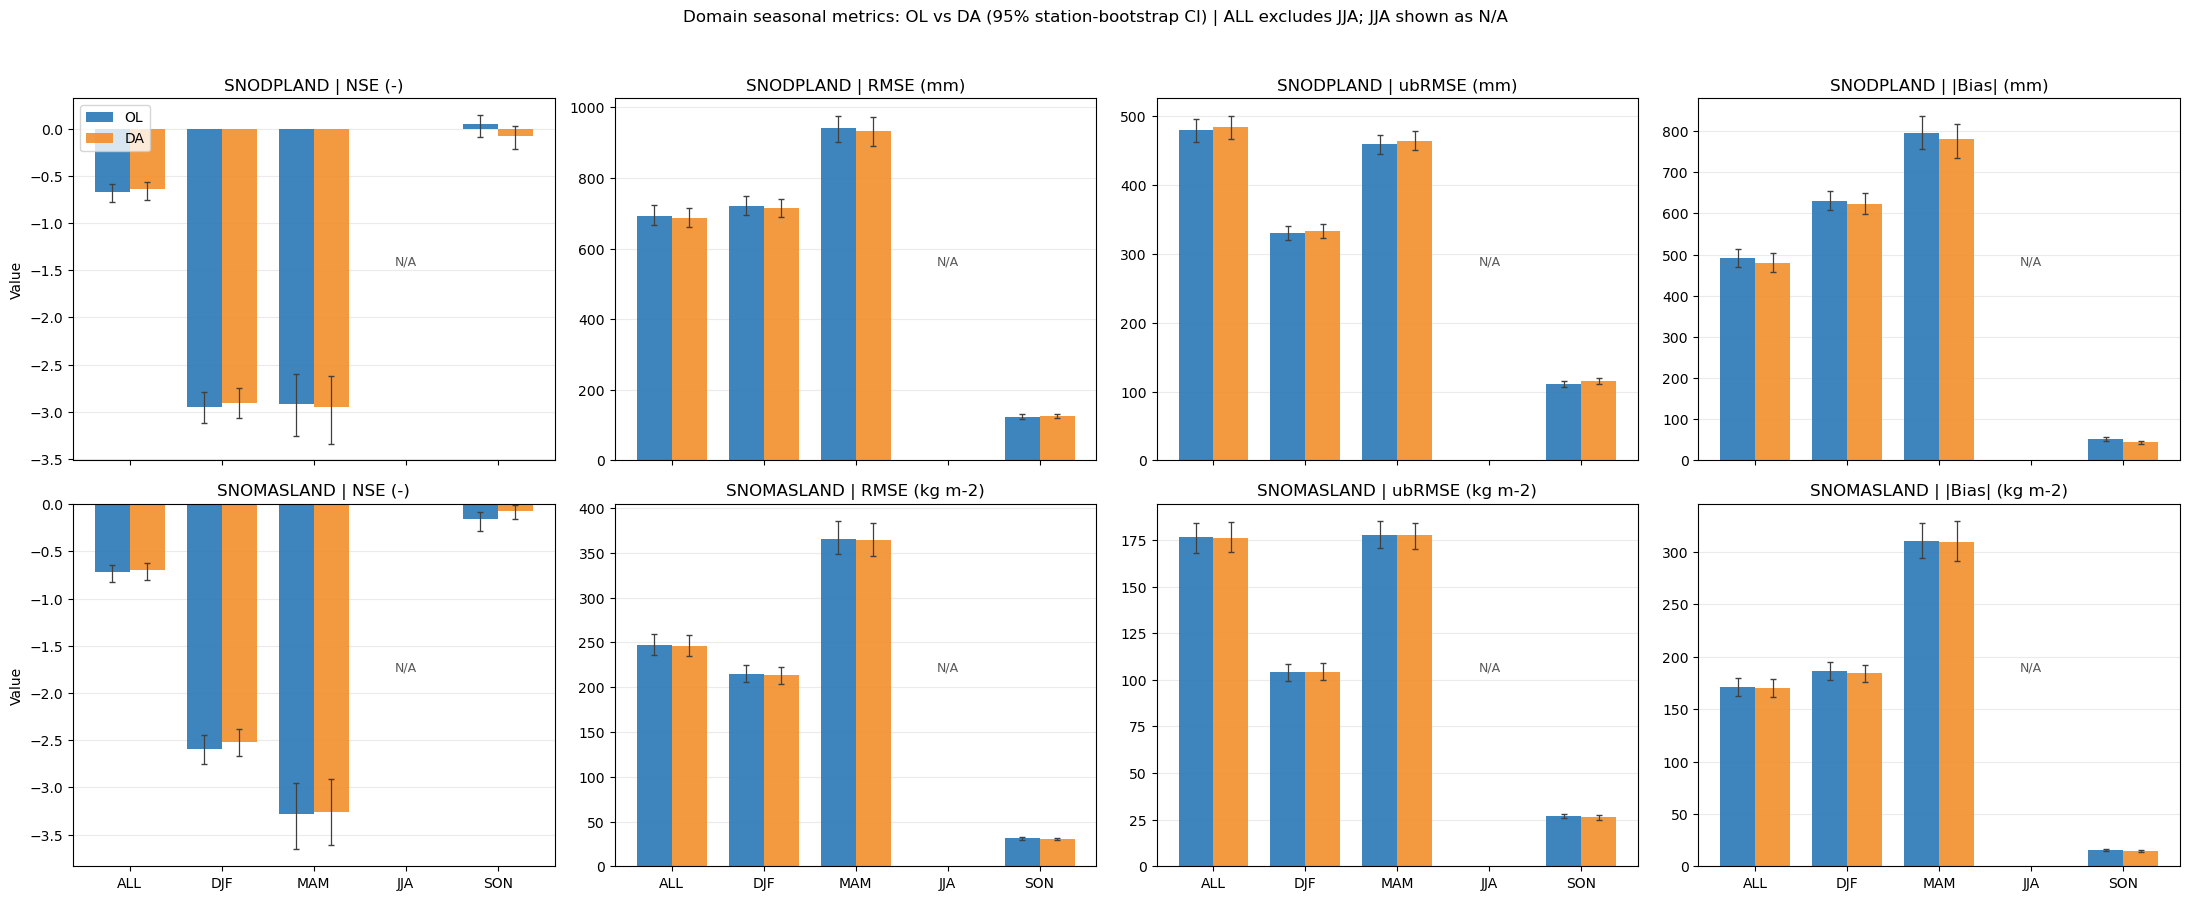

Wrote figure: /Users/amfox/Desktop/geosldas-analysis/projects/SNOTEL/outputs_snotel_ol_da_validation/figures/snotel_domain_ol_da_bars_SMAP_EASEv2_M36_GLOBAL_20000601_20240601.png


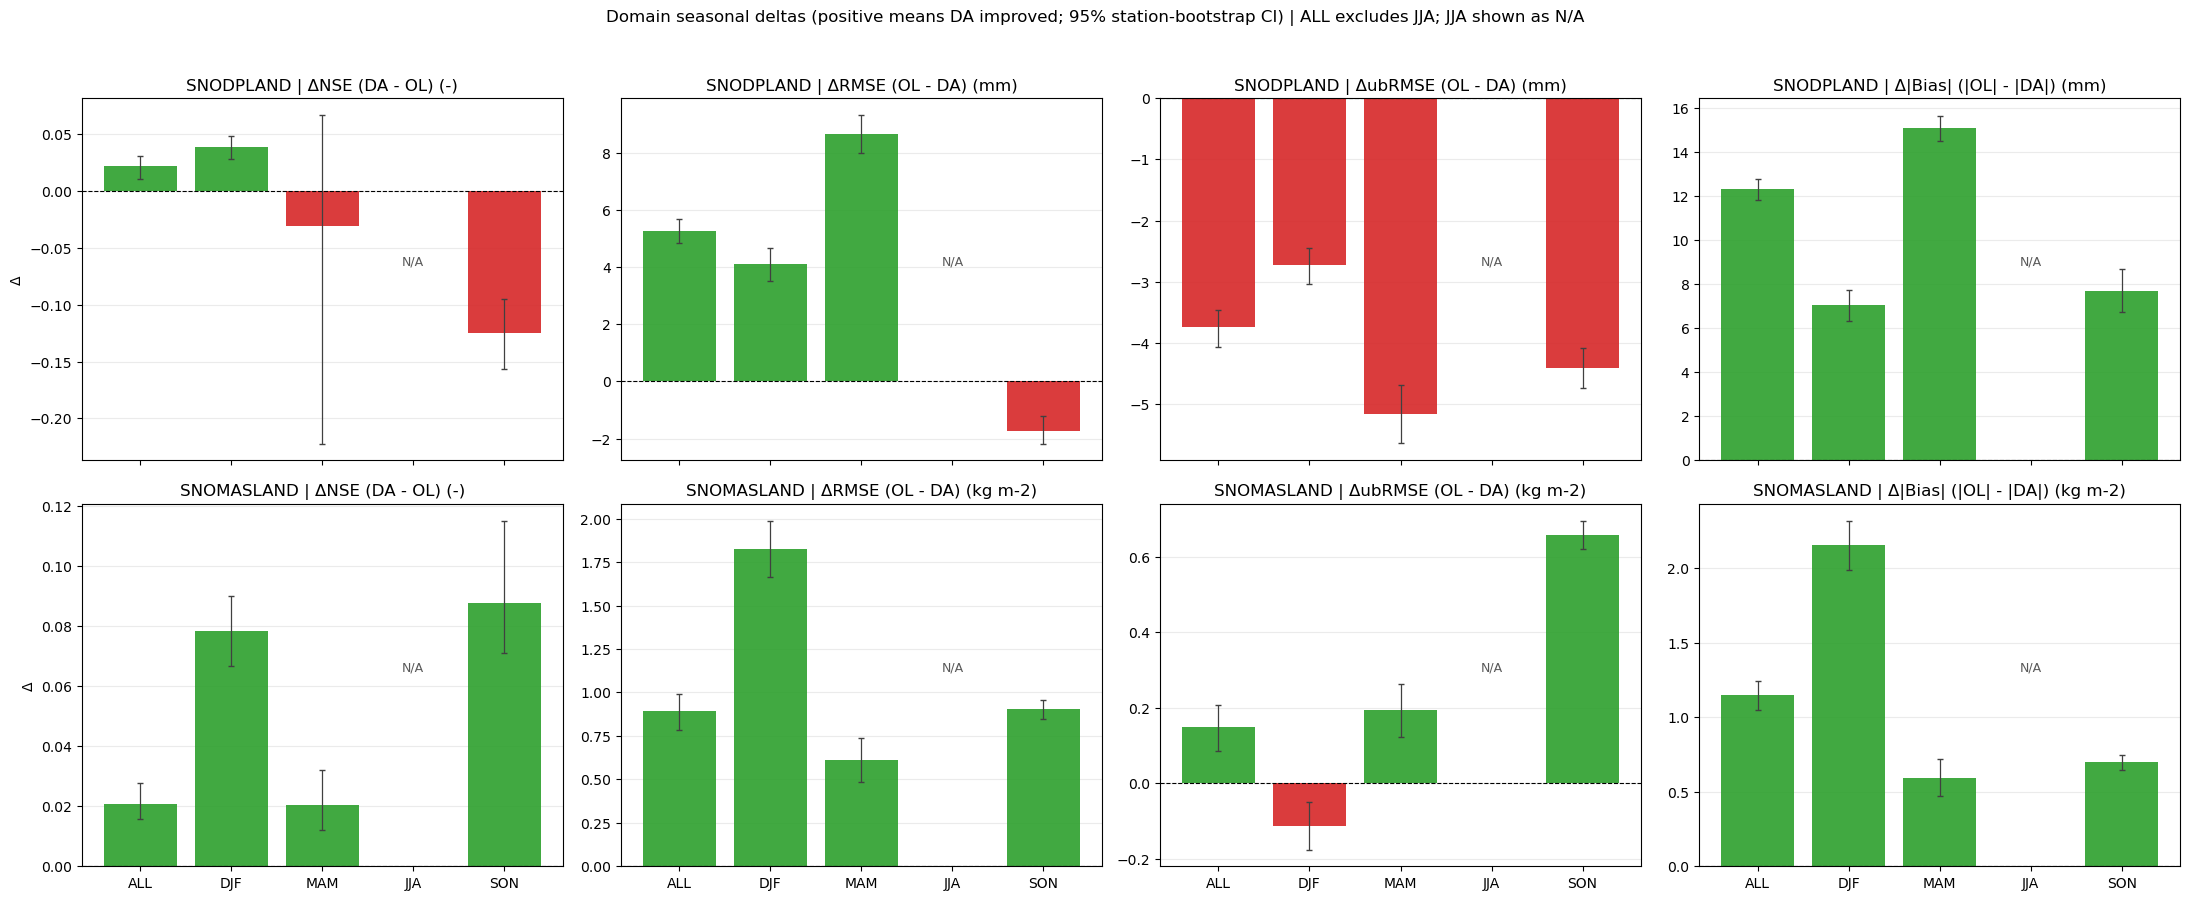

Wrote figure: /Users/amfox/Desktop/geosldas-analysis/projects/SNOTEL/outputs_snotel_ol_da_validation/figures/snotel_domain_delta_bars_SMAP_EASEv2_M36_GLOBAL_20000601_20240601.png


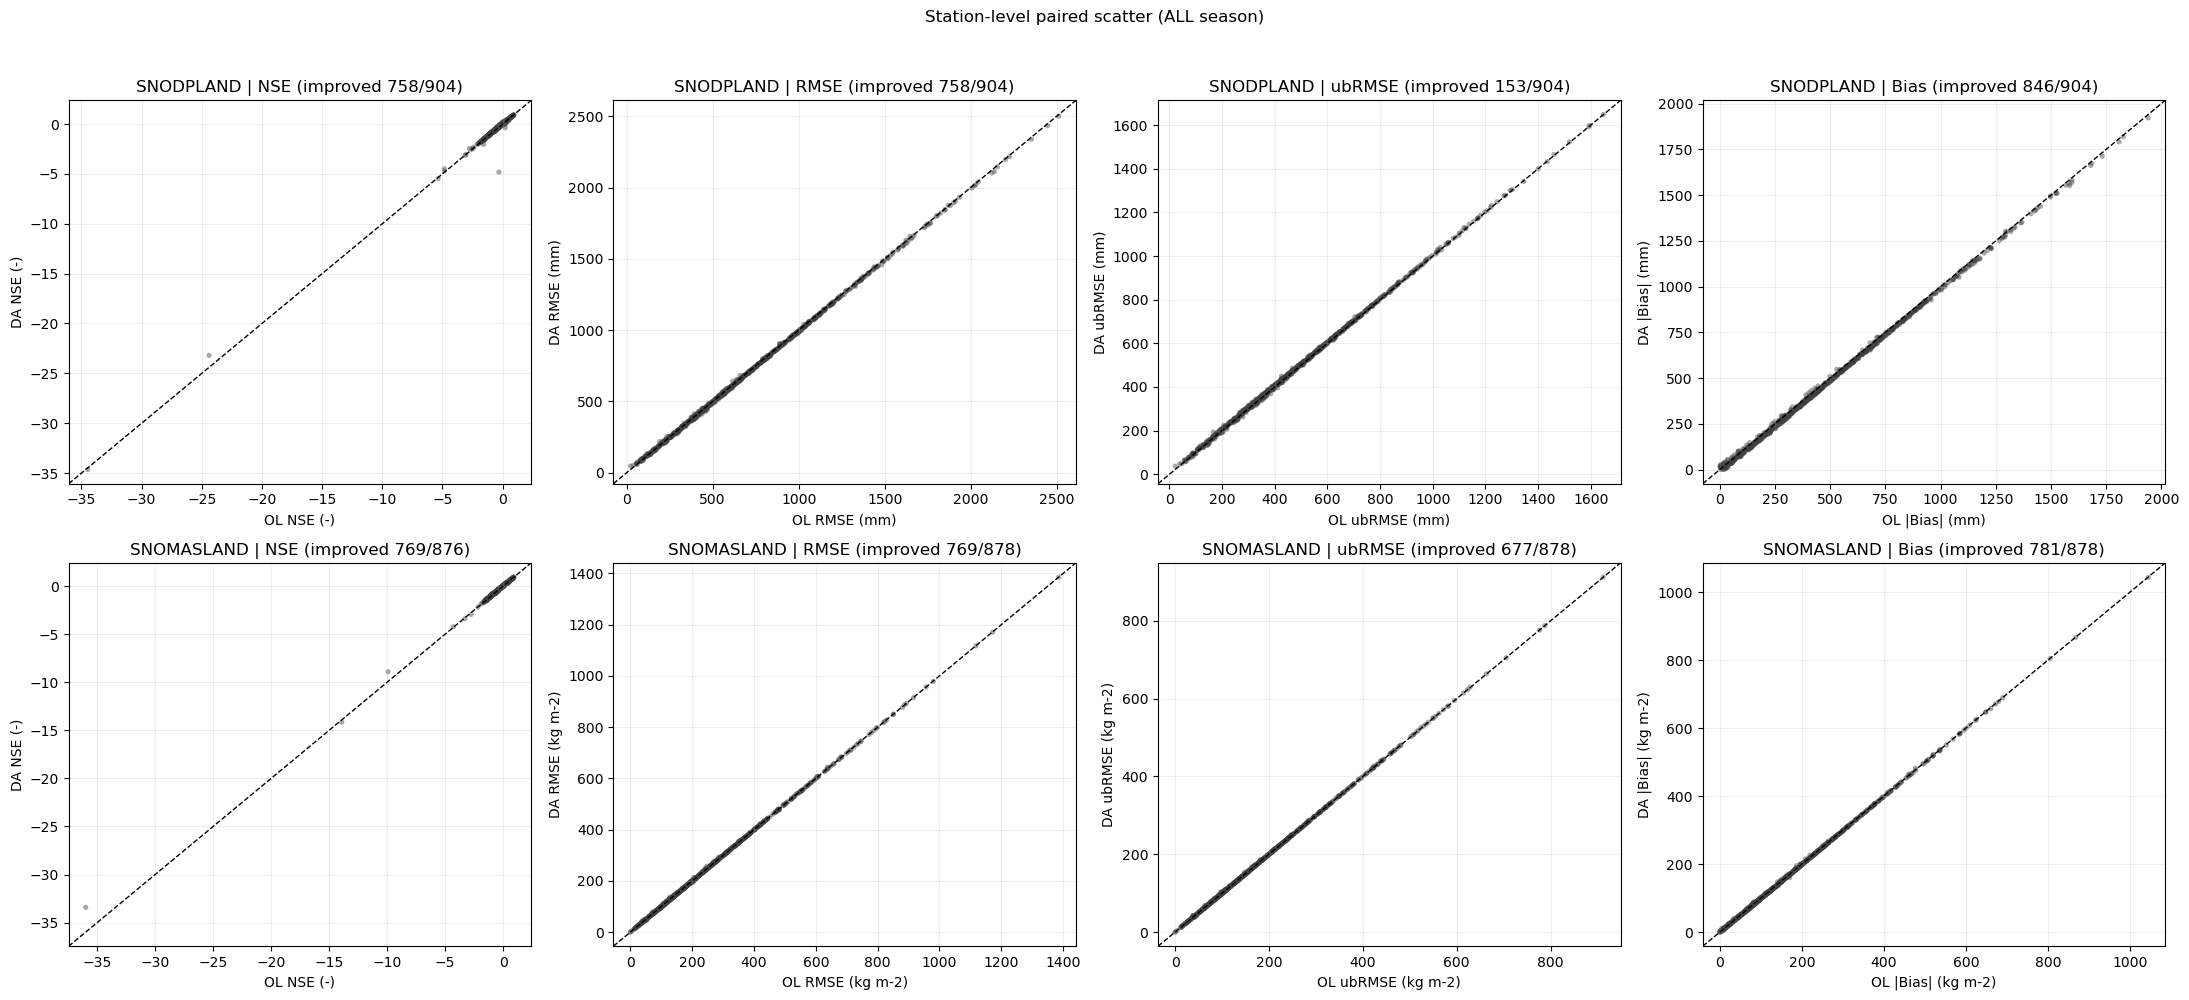

Wrote figure: /Users/amfox/Desktop/geosldas-analysis/projects/SNOTEL/outputs_snotel_ol_da_validation/figures/snotel_station_paired_scatter_all_SMAP_EASEv2_M36_GLOBAL_20000601_20240601.png


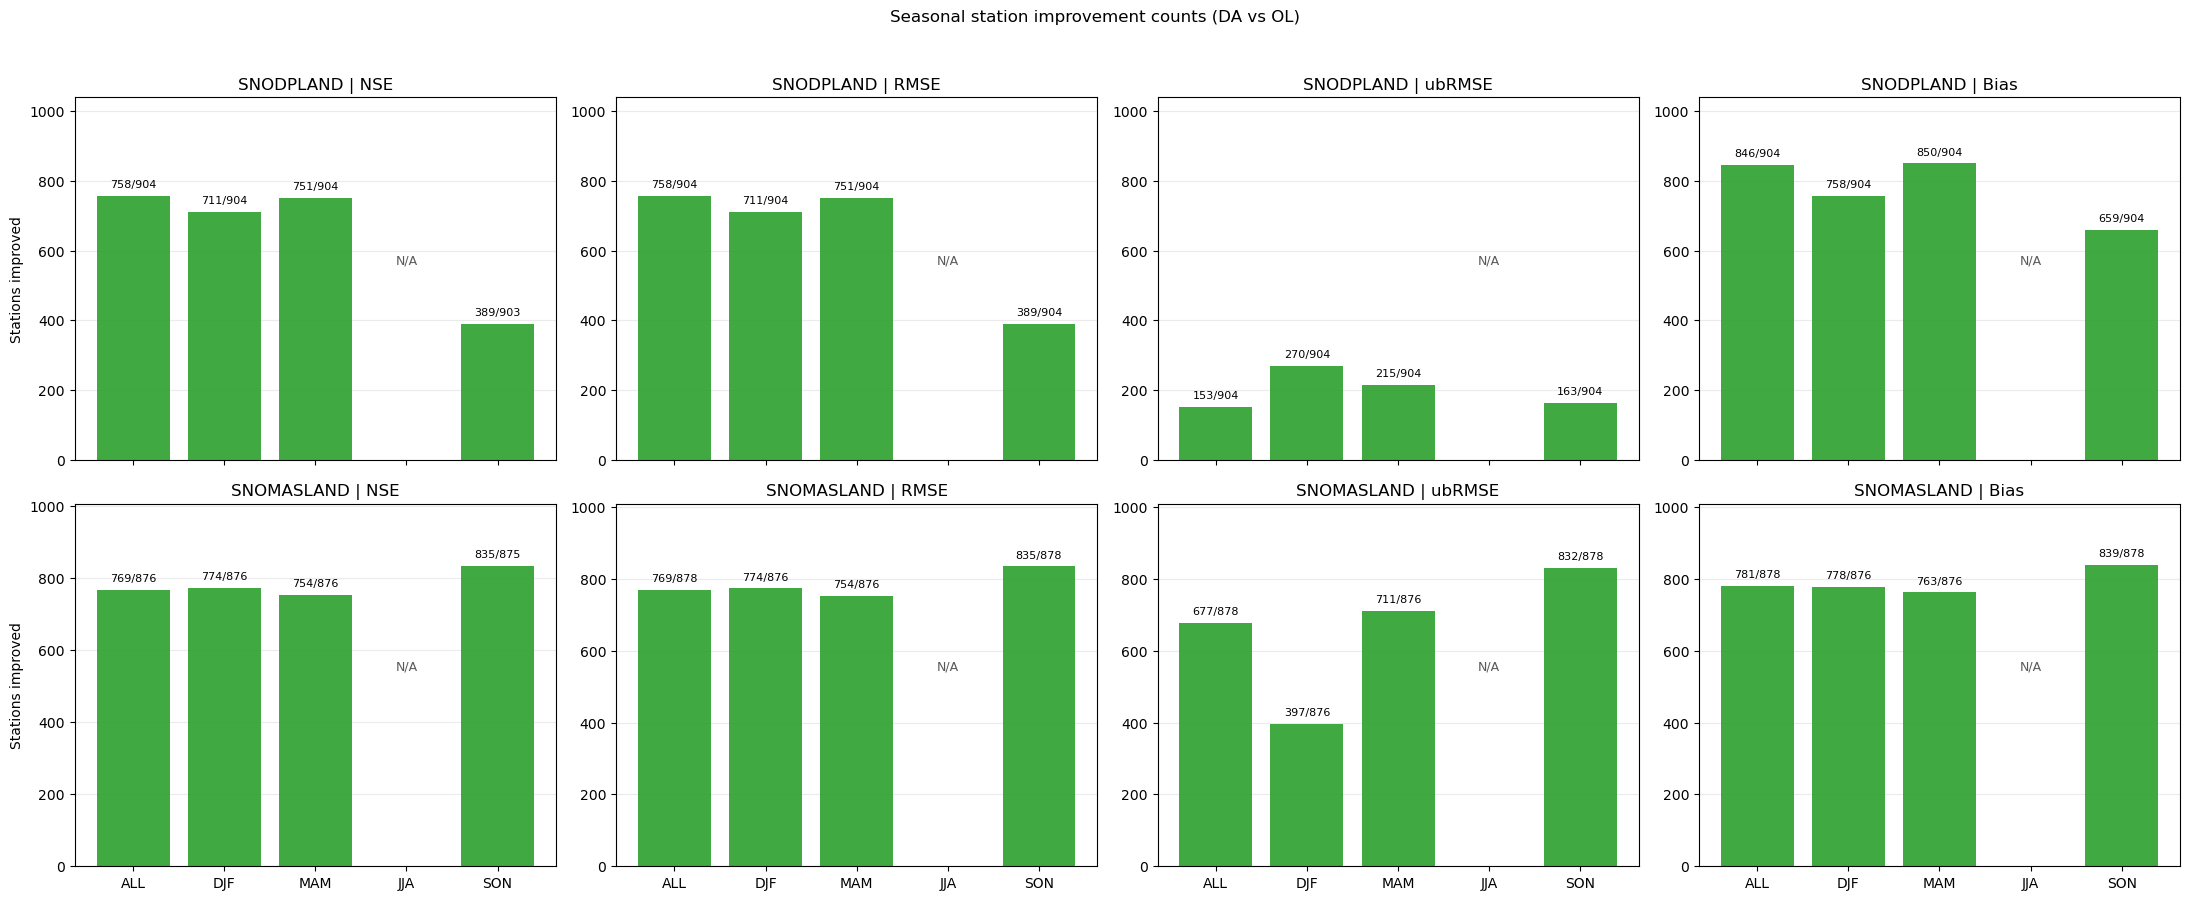

Wrote figure: /Users/amfox/Desktop/geosldas-analysis/projects/SNOTEL/outputs_snotel_ol_da_validation/figures/snotel_station_improvement_counts_SMAP_EASEv2_M36_GLOBAL_20000601_20240601.png


,variable,metric,season,n_improved,n_total,frac_improved
0,SNODPLAND,bias,ALL,846.0,904.0,0.935841
1,SNODPLAND,bias,DJF,758.0,904.0,0.838496
2,SNODPLAND,bias,JJA,NaN,NaN,NaN
3,SNODPLAND,bias,MAM,850.0,904.0,0.940265
4,SNODPLAND,bias,SON,659.0,904.0,0.728982
5,SNODPLAND,nse,ALL,758.0,904.0,0.838496
6,SNODPLAND,nse,DJF,711.0,904.0,0.786504
7,SNODPLAND,nse,JJA,NaN,NaN,NaN
8,SNODPLAND,nse,MAM,751.0,904.0,0.830752
9,SNODPLAND,nse,SON,389.0,903.0,0.430786


In [7]:
# -------------------------
# Visual OL vs DA comparison
# -------------------------
import matplotlib.pyplot as plt

EXP_OL = "OL"
EXP_DA = "DA"
SEASONS_WITH_ALL = ["ALL"] + [s for s in SEASON_ORDER if s != "ALL"]
VAR_ORDER = ["SNODPLAND", "SNOMASLAND"]
METRIC_ORDER = ["nse", "rmse", "ubrmse", "bias"]
METRIC_LABEL = {
    "nse": "NSE",
    "rmse": "RMSE",
    "ubrmse": "ubRMSE",
    "bias": "Bias",
}

OL_COLOR = "#2878B5"
DA_COLOR = "#F28E2B"
POS_COLOR = "#2ca02c"
NEG_COLOR = "#d62728"

BOOT_N = 1000
BOOT_CI = 95.0
BOOT_SEED = 42
PLOT_NA_SEASONS = {"JJA"} if globals().get("EXCLUDE_JJA_FROM_ALL", False) else set()
ALL_DEF_NOTE = "ALL excludes JJA; JJA shown as N/A" if globals().get("EXCLUDE_JJA_FROM_ALL", False) else "ALL includes all months"

FIG_DIR = NOTEBOOK_OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Variable base units from metrics table, e.g., SNODPLAND->m, SNOMASLAND->kg m-2
VAR_BASE_UNIT = (
    station_metrics_df[["variable", "units"]]
    .dropna()
    .drop_duplicates("variable")
    .set_index("variable")["units"]
    .to_dict()
)


def _display_unit(var_name: str, metric: str) -> str:
    if metric == "nse":
        return "-"
    base = str(VAR_BASE_UNIT.get(var_name, "")).strip()
    if base == "m":
        return "mm"
    return base if len(base) > 0 else "-"


def _scale_values(var_name: str, metric: str, x):
    arr = np.asarray(x, dtype=float)
    if metric != "nse" and str(VAR_BASE_UNIT.get(var_name, "")).strip() == "m":
        return arr * 1000.0
    return arr


def _season_is_na(season_key: str) -> bool:
    return season_key in PLOT_NA_SEASONS


def _paired_by_exp(df, key_cols, value_col, exp_col="experiment", ol=EXP_OL, da=EXP_DA):
    out = (
        df.pivot_table(index=key_cols, columns=exp_col, values=value_col, aggfunc="mean")
        .reset_index()
    )
    if ol not in out.columns:
        out[ol] = np.nan
    if da not in out.columns:
        out[da] = np.nan
    return out


def _delta_series(paired_df, metric):
    ol = paired_df[EXP_OL].to_numpy(dtype=float)
    da = paired_df[EXP_DA].to_numpy(dtype=float)
    if metric == "nse":
        return da - ol  # higher is better
    if metric in {"rmse", "ubrmse"}:
        return ol - da  # lower is better, so positive means DA improved
    if metric == "bias":
        return np.abs(ol) - np.abs(da)  # smaller |bias| is better
    raise ValueError(f"Unsupported metric: {metric}")


def _improved_mask(ol, da, metric):
    valid = np.isfinite(ol) & np.isfinite(da)
    improved = np.zeros_like(valid, dtype=bool)
    if metric == "nse":
        improved[valid] = da[valid] > ol[valid]
    elif metric in {"rmse", "ubrmse"}:
        improved[valid] = da[valid] < ol[valid]
    elif metric == "bias":
        improved[valid] = np.abs(da[valid]) < np.abs(ol[valid])
    else:
        raise ValueError(f"Unsupported metric: {metric}")
    return improved, valid


def _bootstrap_mean_ci(vals, n_boot=BOOT_N, ci=BOOT_CI, rng=None):
    x = np.asarray(vals, dtype=float)
    x = x[np.isfinite(x)]
    n = x.size
    if n == 0:
        return np.nan, np.nan, np.nan
    mu = float(np.mean(x))
    if n == 1:
        return mu, mu, mu

    if rng is None:
        rng = np.random.default_rng(BOOT_SEED)

    boot_means = np.empty(int(n_boot), dtype=float)
    for bi in range(int(n_boot)):
        samp = x[rng.integers(0, n, size=n)]
        boot_means[bi] = float(np.mean(samp))

    alpha = (100.0 - float(ci)) / 2.0
    lo = float(np.nanpercentile(boot_means, alpha))
    hi = float(np.nanpercentile(boot_means, 100.0 - alpha))
    return mu, lo, hi


# Build station-bootstrap summaries used in bars/error bars
rng = np.random.default_rng(BOOT_SEED)
domain_boot_rows = []
for var_name in VAR_ORDER:
    for season_key in SEASONS_WITH_ALL:
        for exp_key in [EXP_OL, EXP_DA]:
            sub = station_metrics_df[
                (station_metrics_df["variable"] == var_name)
                & (station_metrics_df["season"] == season_key)
                & (station_metrics_df["experiment"] == exp_key)
            ]
            for metric in METRIC_ORDER:
                if _season_is_na(season_key):
                    mu, lo, hi = np.nan, np.nan, np.nan
                else:
                    vals = sub[metric].to_numpy(dtype=float)
                    if metric == "bias":
                        vals = np.abs(vals)
                    mu, lo, hi = _bootstrap_mean_ci(vals, rng=rng)
                    mu = _scale_values(var_name, metric, mu)
                    lo = _scale_values(var_name, metric, lo)
                    hi = _scale_values(var_name, metric, hi)
                domain_boot_rows.append(
                    {
                        "variable": var_name,
                        "season": season_key,
                        "experiment": exp_key,
                        "metric": metric,
                        "mean": float(mu),
                        "ci_low": float(lo),
                        "ci_high": float(hi),
                    }
                )

domain_boot_df = pd.DataFrame(domain_boot_rows)


delta_boot_rows = []
for var_name in VAR_ORDER:
    for season_key in SEASONS_WITH_ALL:
        for metric in METRIC_ORDER:
            sub = station_metrics_df[
                (station_metrics_df["variable"] == var_name)
                & (station_metrics_df["season"] == season_key)
            ][["station", "experiment", metric]].copy()

            if _season_is_na(season_key):
                mu, lo, hi = np.nan, np.nan, np.nan
            else:
                p = _paired_by_exp(sub, ["station"], metric)
                delta_vals = _delta_series(p, metric)
                mu, lo, hi = _bootstrap_mean_ci(delta_vals, rng=rng)
                mu = _scale_values(var_name, metric, mu)
                lo = _scale_values(var_name, metric, lo)
                hi = _scale_values(var_name, metric, hi)
            delta_boot_rows.append(
                {
                    "variable": var_name,
                    "season": season_key,
                    "metric": metric,
                    "delta_mean": float(mu),
                    "ci_low": float(lo),
                    "ci_high": float(hi),
                }
            )

delta_boot_df = pd.DataFrame(delta_boot_rows)


# 1) Domain seasonal OL-vs-DA bar charts with bootstrap CIs
plot_metrics_domain = ["nse", "rmse", "ubrmse", "bias"]
fig, axs = plt.subplots(len(VAR_ORDER), len(plot_metrics_domain), figsize=(22, 9), sharex=True)
if len(VAR_ORDER) == 1:
    axs = np.array([axs])

for vi, var_name in enumerate(VAR_ORDER):
    for mi, metric in enumerate(plot_metrics_domain):
        ax = axs[vi, mi]
        tmp = domain_boot_df[
            (domain_boot_df["variable"] == var_name)
            & (domain_boot_df["metric"] == metric)
        ].copy()

        p = _paired_by_exp(tmp[["season", "experiment", "mean"]], ["season"], "mean")
        p = p.set_index("season").reindex(SEASONS_WITH_ALL).reset_index()

        ci_ol = (
            tmp[tmp["experiment"] == EXP_OL]
            .set_index("season")
            .reindex(SEASONS_WITH_ALL)
        )
        ci_da = (
            tmp[tmp["experiment"] == EXP_DA]
            .set_index("season")
            .reindex(SEASONS_WITH_ALL)
        )

        y_ol = p[EXP_OL].to_numpy(dtype=float)
        y_da = p[EXP_DA].to_numpy(dtype=float)
        yerr_ol = np.vstack([
            y_ol - ci_ol["ci_low"].to_numpy(dtype=float),
            ci_ol["ci_high"].to_numpy(dtype=float) - y_ol,
        ])
        yerr_da = np.vstack([
            y_da - ci_da["ci_low"].to_numpy(dtype=float),
            ci_da["ci_high"].to_numpy(dtype=float) - y_da,
        ])
        yerr_ol = np.where(np.isfinite(yerr_ol), np.maximum(0.0, yerr_ol), np.nan)
        yerr_da = np.where(np.isfinite(yerr_da), np.maximum(0.0, yerr_da), np.nan)

        x = np.arange(len(SEASONS_WITH_ALL), dtype=float)
        w = 0.38
        ax.bar(
            x - w / 2,
            y_ol,
            width=w,
            color=OL_COLOR,
            label=EXP_OL,
            alpha=0.9,
            yerr=yerr_ol,
            capsize=2,
            error_kw={"elinewidth": 0.9, "ecolor": "0.25"},
        )
        ax.bar(
            x + w / 2,
            y_da,
            width=w,
            color=DA_COLOR,
            label=EXP_DA,
            alpha=0.9,
            yerr=yerr_da,
            capsize=2,
            error_kw={"elinewidth": 0.9, "ecolor": "0.25"},
        )

        ax.set_xticks(x)
        ax.set_xticklabels(SEASONS_WITH_ALL)
        ax.grid(axis="y", alpha=0.25)
        ax.set_axisbelow(True)
        for si, sname in enumerate(SEASONS_WITH_ALL):
            if _season_is_na(sname):
                ax.text(float(si), 0.55, "N/A", ha="center", va="center", fontsize=9, color="0.35", transform=ax.get_xaxis_transform())

        metric_title = "|Bias|" if metric == "bias" else METRIC_LABEL[metric]
        unit = _display_unit(var_name, metric)
        ax.set_title(f"{var_name} | {metric_title} ({unit})")
        if mi == 0:
            ax.set_ylabel("Value")

axs[0, 0].legend(loc="upper left")
fig.suptitle(f"Domain seasonal metrics: OL vs DA (95% station-bootstrap CI) | {ALL_DEF_NOTE}", y=0.995)
plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.97))

fig1_path = FIG_DIR / f"snotel_domain_ol_da_bars_{_cache_tag}.png"
fig.savefig(fig1_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Wrote figure: {fig1_path}")


# 2) Domain seasonal delta bars (positive = DA improvement) with bootstrap CIs
plot_metrics_delta = ["nse", "rmse", "ubrmse", "bias"]

fig, axs = plt.subplots(len(VAR_ORDER), len(plot_metrics_delta), figsize=(22, 9), sharex=True)
if len(VAR_ORDER) == 1:
    axs = np.array([axs])

for vi, var_name in enumerate(VAR_ORDER):
    for mi, metric in enumerate(plot_metrics_delta):
        ax = axs[vi, mi]
        sub = delta_boot_df[
            (delta_boot_df["variable"] == var_name)
            & (delta_boot_df["metric"] == metric)
        ].copy()
        sub = sub.set_index("season").reindex(SEASONS_WITH_ALL).reset_index()

        delta = sub["delta_mean"].to_numpy(dtype=float)
        lo = sub["ci_low"].to_numpy(dtype=float)
        hi = sub["ci_high"].to_numpy(dtype=float)
        yerr = np.vstack([delta - lo, hi - delta])
        yerr = np.where(np.isfinite(yerr), np.maximum(0.0, yerr), np.nan)

        x = np.arange(len(SEASONS_WITH_ALL), dtype=float)
        bar_colors = np.where(np.isfinite(delta) & (delta >= 0), POS_COLOR, NEG_COLOR)

        ax.bar(
            x,
            delta,
            color=bar_colors,
            alpha=0.9,
            yerr=yerr,
            capsize=2,
            error_kw={"elinewidth": 0.9, "ecolor": "0.25"},
        )
        ax.axhline(0.0, color="black", linewidth=0.8, linestyle="--")
        ax.set_xticks(x)
        ax.set_xticklabels(SEASONS_WITH_ALL)
        ax.grid(axis="y", alpha=0.25)
        ax.set_axisbelow(True)
        for si, sname in enumerate(SEASONS_WITH_ALL):
            if _season_is_na(sname):
                ax.text(float(si), 0.55, "N/A", ha="center", va="center", fontsize=9, color="0.35", transform=ax.get_xaxis_transform())

        unit = _display_unit(var_name, metric)
        if metric == "nse":
            delta_label = "ΔNSE (DA - OL)"
        elif metric == "rmse":
            delta_label = "ΔRMSE (OL - DA)"
        elif metric == "ubrmse":
            delta_label = "ΔubRMSE (OL - DA)"
        else:
            delta_label = "Δ|Bias| (|OL| - |DA|)"
        ax.set_title(f"{var_name} | {delta_label} ({unit})")

        if mi == 0:
            ax.set_ylabel("Δ")

fig.suptitle(f"Domain seasonal deltas (positive means DA improved; 95% station-bootstrap CI) | {ALL_DEF_NOTE}", y=0.995)
plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.97))

fig2_path = FIG_DIR / f"snotel_domain_delta_bars_{_cache_tag}.png"
fig.savefig(fig2_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Wrote figure: {fig2_path}")


# 3) Station-level paired scatter for ALL season
fig, axs = plt.subplots(len(VAR_ORDER), len(METRIC_ORDER), figsize=(22, 10))
if len(VAR_ORDER) == 1:
    axs = np.array([axs])

for vi, var_name in enumerate(VAR_ORDER):
    for mi, metric in enumerate(METRIC_ORDER):
        ax = axs[vi, mi]

        sub = station_metrics_df[
            (station_metrics_df["variable"] == var_name)
            & (station_metrics_df["season"] == "ALL")
        ][["station", "experiment", metric]].copy()

        p = _paired_by_exp(sub, ["station"], metric)
        ol = p[EXP_OL].to_numpy(dtype=float)
        da = p[EXP_DA].to_numpy(dtype=float)

        # For bias, compare magnitudes.
        x_vals = np.abs(ol) if metric == "bias" else ol
        y_vals = np.abs(da) if metric == "bias" else da

        # Apply unit scaling (m -> mm for SNODPLAND metrics except NSE)
        x_vals = _scale_values(var_name, metric, x_vals)
        y_vals = _scale_values(var_name, metric, y_vals)

        improved, valid = _improved_mask(ol, da, metric)
        n_valid = int(np.sum(valid))
        n_improved = int(np.sum(improved))

        if n_valid > 0:
            ax.scatter(x_vals[valid], y_vals[valid], s=14, alpha=0.45, color="0.25", edgecolors="none")
            xy = np.concatenate([x_vals[valid], y_vals[valid]])
            lo = float(np.nanmin(xy))
            hi = float(np.nanmax(xy))
            if np.isfinite(lo) and np.isfinite(hi):
                if lo == hi:
                    lo -= 1e-6
                    hi += 1e-6
                pad = 0.04 * (hi - lo)
                lo -= pad
                hi += pad
                ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.0, color="black")
                ax.set_xlim(lo, hi)
                ax.set_ylim(lo, hi)
        else:
            ax.text(0.5, 0.5, "No paired values", ha="center", va="center", transform=ax.transAxes)

        unit = _display_unit(var_name, metric)
        xlabel = f"OL {METRIC_LABEL[metric]} ({unit})"
        ylabel = f"DA {METRIC_LABEL[metric]} ({unit})"
        if metric == "bias":
            xlabel = f"OL |Bias| ({unit})"
            ylabel = f"DA |Bias| ({unit})"

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.2)
        ax.set_title(f"{var_name} | {METRIC_LABEL[metric]} (improved {n_improved}/{n_valid})")

fig.suptitle("Station-level paired scatter (ALL season)", y=0.995)
plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.97))

fig3_path = FIG_DIR / f"snotel_station_paired_scatter_all_{_cache_tag}.png"
fig.savefig(fig3_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Wrote figure: {fig3_path}")


# 4) Improvement-count bars by season
imp_rows = []
for var_name in VAR_ORDER:
    for metric in METRIC_ORDER:
        for season_key in SEASONS_WITH_ALL:
            sub = station_metrics_df[
                (station_metrics_df["variable"] == var_name)
                & (station_metrics_df["season"] == season_key)
            ][["station", "experiment", metric]].copy()

            if _season_is_na(season_key):
                n_total = np.nan
                n_improved = np.nan
                frac = np.nan
            else:
                p = _paired_by_exp(sub, ["station"], metric)
                ol = p[EXP_OL].to_numpy(dtype=float)
                da = p[EXP_DA].to_numpy(dtype=float)
                improved, valid = _improved_mask(ol, da, metric)

                n_total = int(np.sum(valid))
                n_improved = int(np.sum(improved))
                frac = (n_improved / n_total) if n_total > 0 else np.nan

            imp_rows.append(
                {
                    "variable": var_name,
                    "metric": metric,
                    "season": season_key,
                    "n_improved": n_improved,
                    "n_total": n_total,
                    "frac_improved": frac,
                }
            )

imp_df = pd.DataFrame(imp_rows)

fig, axs = plt.subplots(len(VAR_ORDER), len(METRIC_ORDER), figsize=(22, 9), sharex=True)
if len(VAR_ORDER) == 1:
    axs = np.array([axs])

for vi, var_name in enumerate(VAR_ORDER):
    for mi, metric in enumerate(METRIC_ORDER):
        ax = axs[vi, mi]
        sub = imp_df[(imp_df["variable"] == var_name) & (imp_df["metric"] == metric)].copy()
        sub = sub.set_index("season").reindex(SEASONS_WITH_ALL).reset_index()

        x = np.arange(len(SEASONS_WITH_ALL), dtype=float)
        y = sub["n_improved"].to_numpy(dtype=float)
        n_total = sub["n_total"].to_numpy(dtype=float)

        ax.bar(x, y, color=POS_COLOR, alpha=0.9)
        ax.set_xticks(x)
        ax.set_xticklabels(SEASONS_WITH_ALL)
        ax.grid(axis="y", alpha=0.25)
        ax.set_axisbelow(True)

        ymax = float(np.nanmax(n_total)) if np.any(np.isfinite(n_total)) else 1.0
        if not np.isfinite(ymax) or ymax <= 0:
            ymax = 1.0
        ax.set_ylim(0, 1.15 * ymax)

        for xi, yy, tt in zip(x, y, n_total):
            if np.isfinite(tt) and tt > 0:
                ax.text(xi, yy + 0.02 * ymax, f"{int(yy)}/{int(tt)}", ha="center", va="bottom", fontsize=8)
        for si, sname in enumerate(SEASONS_WITH_ALL):
            if _season_is_na(sname):
                ax.text(float(si), 0.55, "N/A", ha="center", va="center", fontsize=9, color="0.35", transform=ax.get_xaxis_transform())

        ax.set_title(f"{var_name} | {METRIC_LABEL[metric]}")
        if mi == 0:
            ax.set_ylabel("Stations improved")

fig.suptitle("Seasonal station improvement counts (DA vs OL)", y=0.995)
plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.97))

fig4_path = FIG_DIR / f"snotel_station_improvement_counts_{_cache_tag}.png"
fig.savefig(fig4_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Wrote figure: {fig4_path}")


display(
    imp_df.sort_values(["variable", "metric", "season"]).reset_index(drop=True).head(20)
)


/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: inv

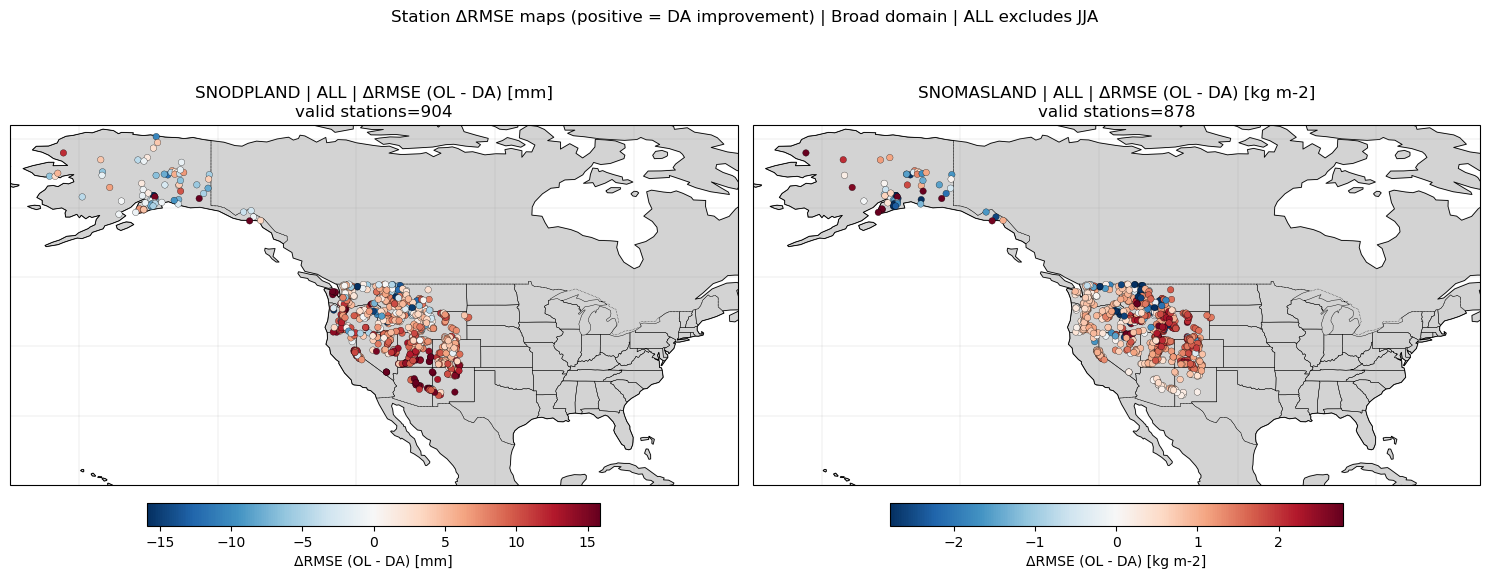

Wrote figure: /Users/amfox/Desktop/geosldas-analysis/projects/SNOTEL/outputs_snotel_ol_da_validation/figures/snotel_station_delta_rmse_map_all_broad_SMAP_EASEv2_M36_GLOBAL_20000601_20240601.png


/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: inv

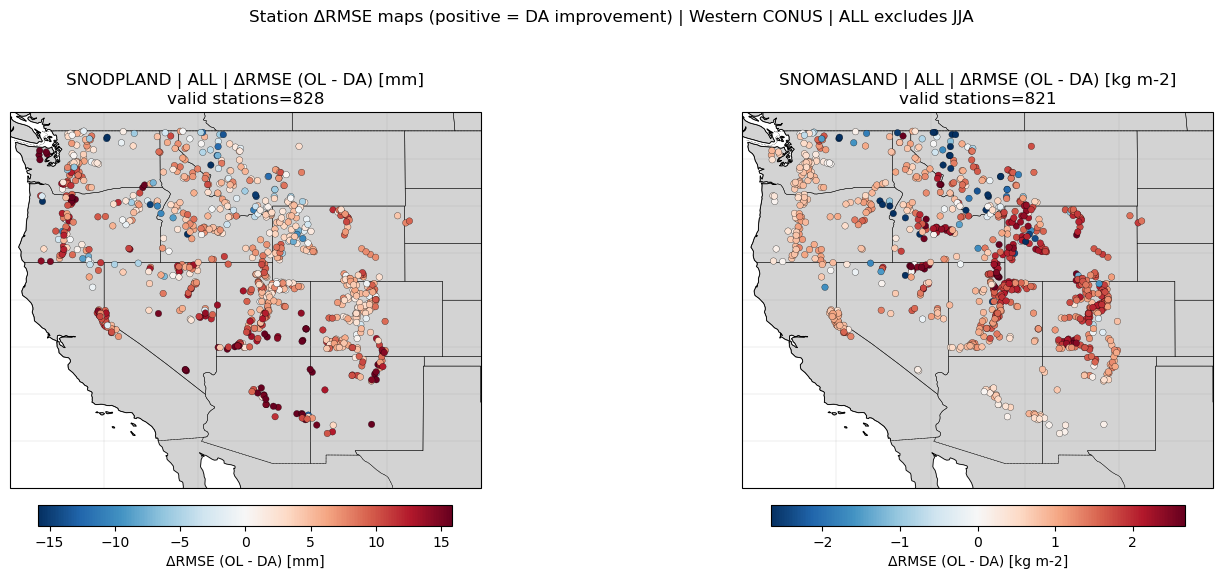

Wrote figure: /Users/amfox/Desktop/geosldas-analysis/projects/SNOTEL/outputs_snotel_ol_da_validation/figures/snotel_station_delta_rmse_map_all_west_conus_SMAP_EASEv2_M36_GLOBAL_20000601_20240601.png


In [8]:
# -------------------------
# Cartopy maps: station ΔRMSE (OL - DA) for ALL
# -------------------------
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
except Exception as exc:
    print(f"Cartopy not available ({exc}); skipping map cell.")
else:
    FIG_DIR_MAP = NOTEBOOK_OUTPUT_DIR / "figures"
    FIG_DIR_MAP.mkdir(parents=True, exist_ok=True)

    all_def_note = "ALL excludes JJA" if globals().get("EXCLUDE_JJA_FROM_ALL", False) else "ALL includes all months"

    var_cfg = [
        ("SNODPLAND", "mm"),
        ("SNOMASLAND", "kg m-2"),
    ]

    proj = ccrs.PlateCarree()

    # Shared fixed western-CONUS map extent used across map cells.
    WEST_CONUS_EXTENT = list(globals().get("WEST_CONUS_EXTENT", [-125.0, -100.0, 30.0, 50.0]))
    globals()["WEST_CONUS_EXTENT"] = WEST_CONUS_EXTENT

    def _build_delta_rmse_df(var_name, unit_label):
        sub = station_metrics_df[
            (station_metrics_df["variable"] == var_name)
            & (station_metrics_df["season"] == "ALL")
        ][["station", "experiment", "rmse", "station_lat", "station_lon"]].copy()

        piv = sub.pivot_table(index="station", columns="experiment", values="rmse", aggfunc="mean")
        lat_s = sub.groupby("station")["station_lat"].first()
        lon_s = sub.groupby("station")["station_lon"].first()

        m = piv.join(lat_s, how="inner").join(lon_s, how="inner")
        if "OL" not in m.columns:
            m["OL"] = np.nan
        if "DA" not in m.columns:
            m["DA"] = np.nan

        m["delta_rmse"] = m["OL"].astype(float) - m["DA"].astype(float)  # positive => DA improved
        if unit_label == "mm":
            m["delta_rmse"] = m["delta_rmse"] * 1000.0

        m = m.reset_index(drop=True)
        m["station_lat"] = pd.to_numeric(m["station_lat"], errors="coerce")
        m["station_lon"] = pd.to_numeric(m["station_lon"], errors="coerce")
        m["delta_rmse"] = pd.to_numeric(m["delta_rmse"], errors="coerce")
        return m

    def _plot_delta_maps(extent, suffix, title_region, mask_fn=None):
        fig, axes = plt.subplots(1, len(var_cfg), figsize=(15, 5.8), subplot_kw={"projection": proj})
        if len(var_cfg) == 1:
            axes = [axes]

        for ax, (var_name, unit_label) in zip(axes, var_cfg):
            m = _build_delta_rmse_df(var_name, unit_label)

            lon = m["station_lon"].to_numpy(dtype=float)
            lat = m["station_lat"].to_numpy(dtype=float)
            val = m["delta_rmse"].to_numpy(dtype=float)

            valid = np.isfinite(val) & np.isfinite(lat) & np.isfinite(lon)
            if mask_fn is not None:
                valid &= mask_fn(lon, lat)

            n_valid = int(np.sum(valid))
            vals = val[valid]

            if n_valid > 0:
                vmax = float(np.nanpercentile(np.abs(vals), 95))
                if not np.isfinite(vmax) or vmax <= 0:
                    vmax = float(np.nanmax(np.abs(vals))) if np.any(np.isfinite(vals)) else 1.0
                if not np.isfinite(vmax) or vmax <= 0:
                    vmax = 1.0

                sc = ax.scatter(
                    lon[valid],
                    lat[valid],
                    c=vals,
                    cmap="RdBu_r",
                    vmin=-vmax,
                    vmax=vmax,
                    s=22,
                    edgecolor="k",
                    linewidths=0.2,
                    transform=proj,
                    zorder=3,
                )
                cbar = fig.colorbar(sc, ax=ax, orientation="horizontal", pad=0.04, fraction=0.05)
                cbar.set_label(f"ΔRMSE (OL - DA) [{unit_label}]")
            else:
                ax.text(0.5, 0.5, "No valid stations", transform=ax.transAxes, ha="center", va="center")

            ax.add_feature(cfeature.LAND, color="lightgray", zorder=0)
            ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
            ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=":")
            try:
                ax.add_feature(cfeature.STATES, linewidth=0.3)
            except Exception:
                pass

            ax.set_extent(extent, crs=proj)
            ax.set_title(f"{var_name} | ALL | ΔRMSE (OL - DA) [{unit_label}]\nvalid stations={n_valid}")
            ax.gridlines(draw_labels=False, linewidth=0.25, color="0.6", alpha=0.5)

        fig.suptitle(
            f"Station ΔRMSE maps (positive = DA improvement) | {title_region} | {all_def_note}",
            y=0.99,
        )
        plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))

        map_path = FIG_DIR_MAP / f"snotel_station_delta_rmse_map_all_{suffix}_{_cache_tag}.png"
        fig.savefig(map_path, dpi=220, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"Wrote figure: {map_path}")

    # Pair 1: broad SNOTEL domain (CONUS + Alaska coverage)
    _plot_delta_maps(
        extent=[-170, -65, 20, 72],
        suffix="broad",
        title_region="Broad domain",
        mask_fn=None,
    )

    # Pair 2: western CONUS only, using observed station footprint.
    def _west_mask(lon, lat):
        return (
            (lon >= WEST_CONUS_EXTENT[0])
            & (lon <= WEST_CONUS_EXTENT[1])
            & (lat >= WEST_CONUS_EXTENT[2])
            & (lat <= WEST_CONUS_EXTENT[3])
        )

    # Fixed extent to keep western-CONUS map framing identical across map cells.
    west_extent = WEST_CONUS_EXTENT

    _plot_delta_maps(
        extent=west_extent,
        suffix="west_conus",
        title_region="Western CONUS",
        mask_fn=_west_mask,
    )


## Notes

- `tile_elev_m` comes from GEOSldas tilecoord (`read_tilecoord(...)["elev"]`).
- `station_elev_raw` is from SNOTEL metadata in the parquet file.
- `station_elev_m` is only populated if `SNOTEL_ELEVATION_UNITS` is set to `"ft"` or `"m"`.
- `elev_diff_m = tile_elev_m - station_elev_m` is only meaningful when `station_elev_m` is valid.


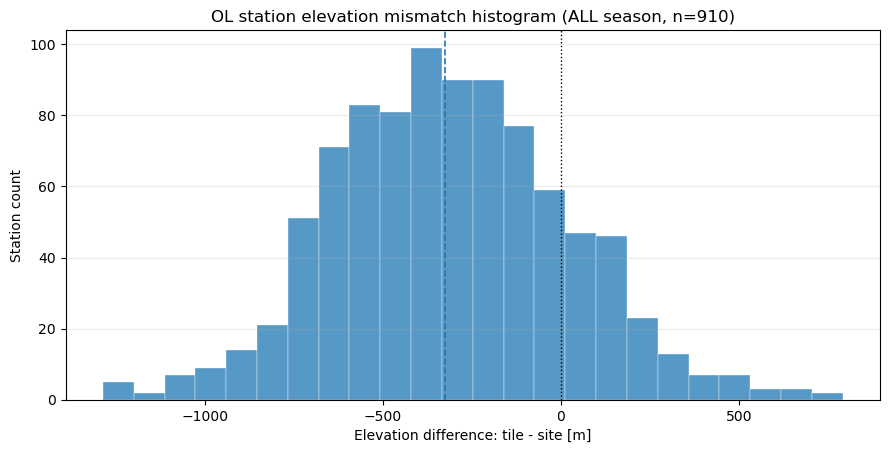

Elevation difference summary [m] (tile - site), OL only:


,count,mean,median,std,min,max
OL,910.0,-310.5,-324.8,328.69,-1285.69,790.4


Wrote figure: /Users/amfox/Desktop/geosldas-analysis/projects/SNOTEL/outputs_snotel_ol_da_validation/figures/snotel_station_tile_elev_diff_hist_ol_SMAP_EASEv2_M36_GLOBAL_20000601_20240601.png


In [9]:
# -------------------------
# Elevation mismatch histogram: model tile minus site elevation (OL mapping)
# -------------------------
if "station_metrics_df" not in globals():
    raise NameError("station_metrics_df not found. Run the metrics cell first.")

required_cols = {"station", "experiment", "season", "elev_diff_m"}
missing_cols = required_cols - set(station_metrics_df.columns)
if missing_cols:
    raise KeyError(f"station_metrics_df missing required columns: {sorted(missing_cols)}")

elev_df = station_metrics_df.loc[
    (station_metrics_df["season"] == "ALL") & (station_metrics_df["experiment"] == "OL"),
    ["station", "elev_diff_m"],
].copy()

# One value per station (avoid repeats across variables/metrics).
elev_df = elev_df.drop_duplicates(subset=["station"])
elev_df["elev_diff_m"] = pd.to_numeric(elev_df["elev_diff_m"], errors="coerce")
elev_df = elev_df[np.isfinite(elev_df["elev_diff_m"])].copy()

if elev_df.empty:
    print("No valid OL elevation-difference values found for histogram.")
else:
    vals = elev_df["elev_diff_m"].to_numpy(dtype=float)

    bins = np.histogram_bin_edges(vals, bins="fd")
    if bins.size < 10:
        vmin = float(np.nanmin(vals))
        vmax = float(np.nanmax(vals))
        if np.isfinite(vmin) and np.isfinite(vmax) and vmax > vmin:
            bins = np.linspace(vmin, vmax, 21)
        else:
            center = float(vmin) if np.isfinite(vmin) else 0.0
            bins = np.linspace(center - 1.0, center + 1.0, 21)

    fig, ax = plt.subplots(figsize=(10.5, 4.8))
    ax.hist(
        vals,
        bins=bins,
        alpha=0.75,
        color="tab:blue",
        edgecolor="white",
        linewidth=0.35,
    )
    ax.axvline(float(np.nanmedian(vals)), color="tab:blue", linestyle="--", linewidth=1.2)
    ax.axvline(0.0, color="k", linestyle=":", linewidth=1.0)

    ax.set_xlabel("Elevation difference: tile - site [m]")
    ax.set_ylabel("Station count")
    ax.set_title(f"OL station elevation mismatch histogram (ALL season, n={vals.size})")
    ax.grid(True, axis="y", alpha=0.25)

    out_hist = NOTEBOOK_OUTPUT_DIR / "figures" / f"snotel_station_tile_elev_diff_hist_ol_{_cache_tag}.png"
    out_hist.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_hist, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    summary = (
        elev_df["elev_diff_m"]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .to_frame(name="OL")
        .T
        .round(2)
    )
    print("Elevation difference summary [m] (tile - site), OL only:")
    display(summary)
    print(f"Wrote figure: {out_hist}")


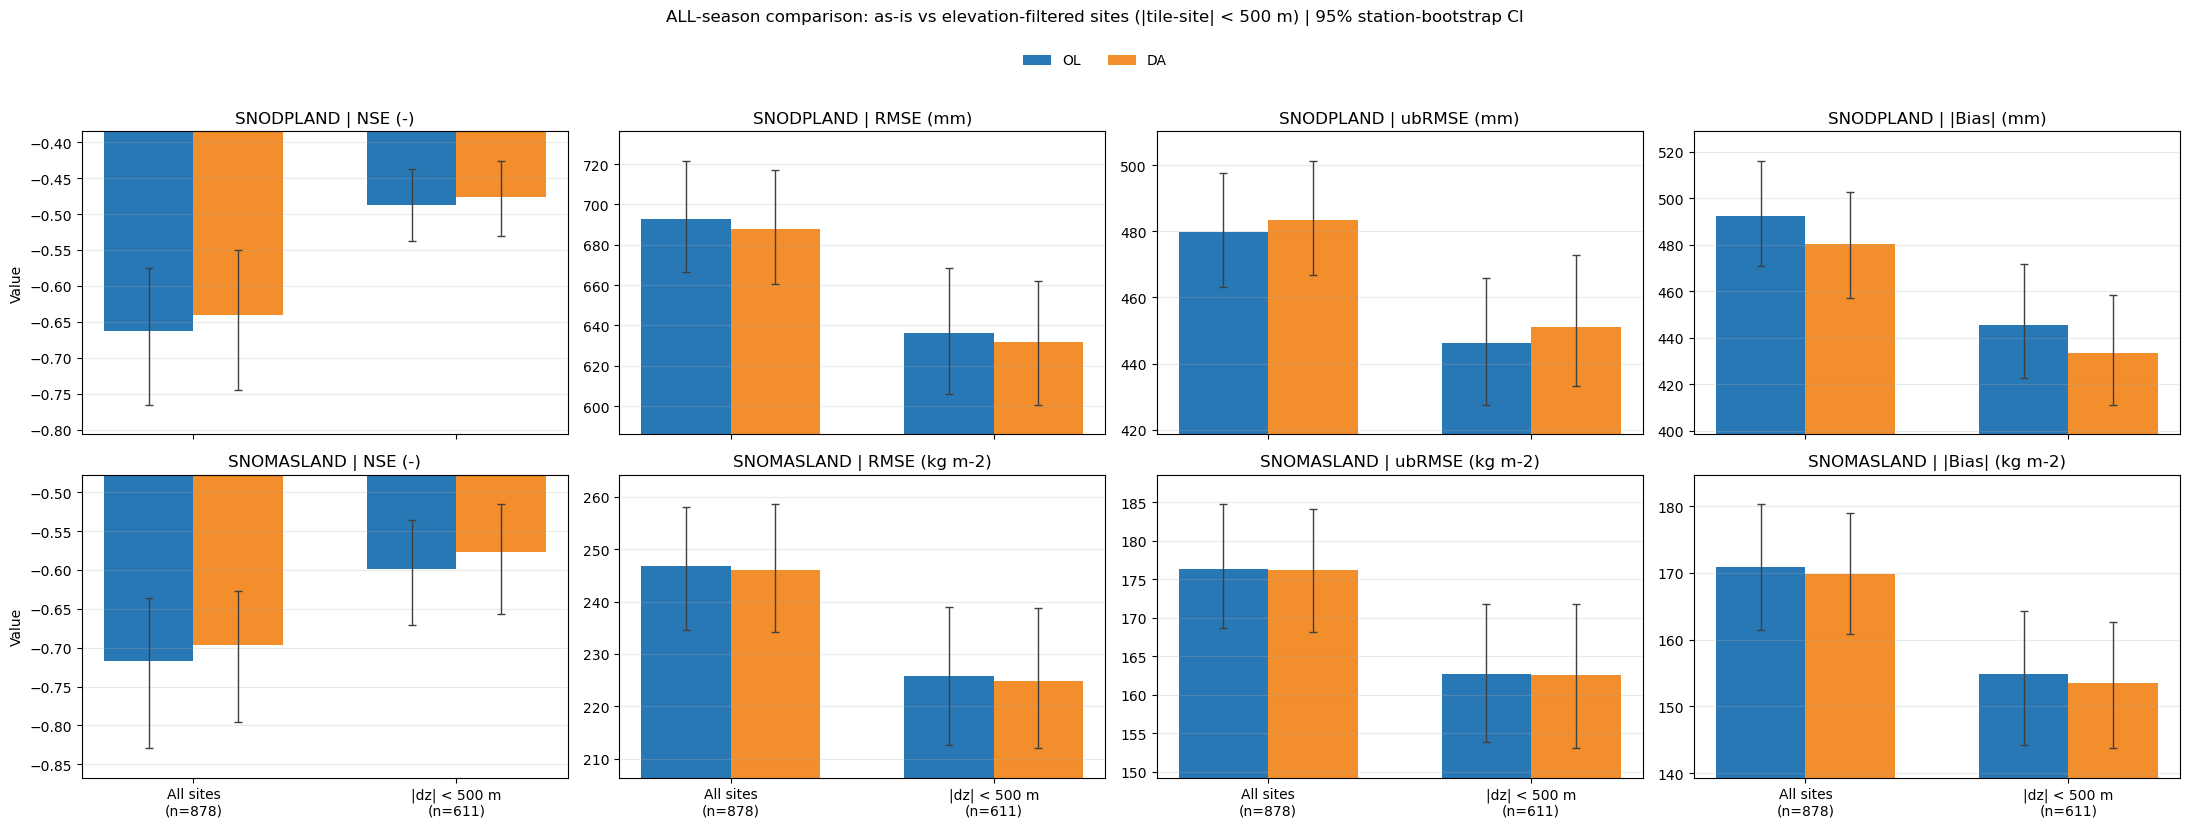

Paired ALL-season means with bootstrap CI (delta_improve > 0 means DA improved):


,variable,metric,unit,case,n_pair,ol_mean,ol_ci_low,ol_ci_high,da_mean,da_ci_low,da_ci_high,delta_improve,delta_ci_low,delta_ci_high
0,SNODPLAND,bias,mm,All sites,904,492.575,470.965,516.213,480.267,457.252,502.878,12.309,11.794,12.785
1,SNODPLAND,bias,mm,|dz| < 500 m,630,445.609,422.592,471.598,433.468,411.076,458.478,12.141,11.464,12.747
2,SNODPLAND,nse,-,All sites,904,-0.663,-0.765,-0.576,-0.641,-0.745,-0.550,0.022,0.009,0.030
3,SNODPLAND,nse,-,|dz| < 500 m,630,-0.488,-0.537,-0.438,-0.476,-0.530,-0.426,0.012,-0.007,0.022
4,SNODPLAND,rmse,mm,All sites,904,692.975,666.357,721.734,687.701,660.494,716.955,5.274,4.835,5.703
5,SNODPLAND,rmse,mm,|dz| < 500 m,630,636.121,605.987,668.491,631.961,600.621,662.223,4.159,3.684,4.645
6,SNODPLAND,ubrmse,mm,All sites,904,479.803,463.240,497.696,483.545,466.878,501.393,-3.742,-4.047,-3.438
7,SNODPLAND,ubrmse,mm,|dz| < 500 m,630,446.313,427.482,465.977,451.127,433.057,472.875,-4.814,-5.121,-4.483
8,SNOMASLAND,bias,kg m-2,All sites,878,170.962,161.415,180.327,169.814,160.862,179.053,1.149,1.039,1.251
9,SNOMASLAND,bias,kg m-2,|dz| < 500 m,611,154.788,144.170,164.343,153.485,143.723,162.596,1.303,1.180,1.430


Wrote figure: /Users/amfox/Desktop/geosldas-analysis/projects/SNOTEL/outputs_snotel_ol_da_validation/figures/snotel_all_stats_compare_elev_filter_bootci_SMAP_EASEv2_M36_GLOBAL_20000601_20240601.png


In [10]:
# -------------------------
# Compare ALL metrics: as-is vs |tile-site elevation difference| < 500 m
# -------------------------
import matplotlib.pyplot as plt

if "station_metrics_df" not in globals():
    raise NameError("station_metrics_df not found. Run the metrics cell first.")

required_cols = {"station", "experiment", "season", "variable", "elev_diff_m", "nse", "rmse", "ubrmse", "bias"}
missing_cols = required_cols - set(station_metrics_df.columns)
if missing_cols:
    raise KeyError(f"station_metrics_df missing required columns: {sorted(missing_cols)}")

EXP_OL = "OL"
EXP_DA = "DA"
ELEV_THRESH_M = 500.0
SEASON_KEY = "ALL"

BOOT_N_CMP = 1000
BOOT_CI_CMP = 95.0
BOOT_SEED_CMP = 314

var_pref = ["SNODPLAND", "SNOMASLAND"]
VAR_ORDER_CMP = [v for v in var_pref if v in set(station_metrics_df["variable"].dropna().unique())]
if not VAR_ORDER_CMP:
    VAR_ORDER_CMP = sorted(station_metrics_df["variable"].dropna().unique().tolist())

METRIC_ORDER_CMP = ["nse", "rmse", "ubrmse", "bias"]
METRIC_LABEL = {
    "nse": "NSE",
    "rmse": "RMSE",
    "ubrmse": "ubRMSE",
    "bias": "|Bias|",
}

OL_COLOR = "#2878B5"
DA_COLOR = "#F28E2B"

fig_dir_local = NOTEBOOK_OUTPUT_DIR / "figures"
fig_dir_local.mkdir(parents=True, exist_ok=True)

var_base_unit = (
    station_metrics_df[["variable", "units"]]
    .dropna()
    .drop_duplicates("variable")
    .set_index("variable")["units"]
    .to_dict()
)


def _disp_unit(var_name: str, metric: str) -> str:
    if metric == "nse":
        return "-"
    base = str(var_base_unit.get(var_name, "")).strip()
    if base == "m":
        return "mm"
    return base if len(base) > 0 else "-"


def _scale_vals(var_name: str, metric: str, x):
    arr = np.asarray(x, dtype=float)
    if metric != "nse" and str(var_base_unit.get(var_name, "")).strip() == "m":
        return arr * 1000.0
    return arr


def _bootstrap_mean_ci(vals, n_boot=BOOT_N_CMP, ci=BOOT_CI_CMP, rng=None):
    x = np.asarray(vals, dtype=float)
    x = x[np.isfinite(x)]
    n = x.size
    if n == 0:
        return np.nan, np.nan, np.nan
    mu = float(np.mean(x))
    if n == 1:
        return mu, mu, mu
    if rng is None:
        rng = np.random.default_rng(BOOT_SEED_CMP)

    idx = rng.integers(0, n, size=(int(n_boot), n))
    boot_means = x[idx].mean(axis=1)
    alpha = (100.0 - float(ci)) / 2.0
    lo = float(np.nanpercentile(boot_means, alpha))
    hi = float(np.nanpercentile(boot_means, 100.0 - alpha))
    return mu, lo, hi


all_station_set = set(
    station_metrics_df.loc[station_metrics_df["season"] == SEASON_KEY, "station"].dropna().unique().tolist()
)

ol_elev = station_metrics_df.loc[
    (station_metrics_df["season"] == SEASON_KEY) & (station_metrics_df["experiment"] == EXP_OL),
    ["station", "elev_diff_m"],
].drop_duplicates(subset=["station"])

ol_elev["elev_diff_m"] = pd.to_numeric(ol_elev["elev_diff_m"], errors="coerce")
filt_station_set = set(
    ol_elev.loc[np.isfinite(ol_elev["elev_diff_m"]) & (np.abs(ol_elev["elev_diff_m"]) < ELEV_THRESH_M), "station"]
    .dropna()
    .unique()
    .tolist()
)

case_defs = [
    ("All sites", all_station_set),
    (f"|dz| < {int(ELEV_THRESH_M)} m", filt_station_set),
]

rng_cmp = np.random.default_rng(BOOT_SEED_CMP)


def _paired_case_stats(var_name: str, metric: str, station_set):
    sub = station_metrics_df.loc[
        (station_metrics_df["variable"] == var_name)
        & (station_metrics_df["season"] == SEASON_KEY)
        & (station_metrics_df["station"].isin(station_set)),
        ["station", "experiment", metric],
    ].copy()

    p = sub.pivot_table(index="station", columns="experiment", values=metric, aggfunc="mean")
    if EXP_OL not in p.columns:
        p[EXP_OL] = np.nan
    if EXP_DA not in p.columns:
        p[EXP_DA] = np.nan

    ol = pd.to_numeric(p[EXP_OL], errors="coerce").to_numpy(dtype=float)
    da = pd.to_numeric(p[EXP_DA], errors="coerce").to_numpy(dtype=float)

    if metric == "bias":
        ol = np.abs(ol)
        da = np.abs(da)

    ol = _scale_vals(var_name, metric, ol)
    da = _scale_vals(var_name, metric, da)

    valid = np.isfinite(ol) & np.isfinite(da)
    n_pair = int(np.sum(valid))
    if n_pair == 0:
        return {
            "ol_mean": np.nan,
            "ol_ci_low": np.nan,
            "ol_ci_high": np.nan,
            "da_mean": np.nan,
            "da_ci_low": np.nan,
            "da_ci_high": np.nan,
            "delta_improve": np.nan,
            "delta_ci_low": np.nan,
            "delta_ci_high": np.nan,
            "n_pair": 0,
        }

    ol_v = ol[valid]
    da_v = da[valid]

    ol_mean, ol_lo, ol_hi = _bootstrap_mean_ci(ol_v, rng=rng_cmp)
    da_mean, da_lo, da_hi = _bootstrap_mean_ci(da_v, rng=rng_cmp)

    if metric == "nse":
        d = da_v - ol_v
    else:
        d = ol_v - da_v
    d_mean, d_lo, d_hi = _bootstrap_mean_ci(d, rng=rng_cmp)

    return {
        "ol_mean": float(ol_mean),
        "ol_ci_low": float(ol_lo),
        "ol_ci_high": float(ol_hi),
        "da_mean": float(da_mean),
        "da_ci_low": float(da_lo),
        "da_ci_high": float(da_hi),
        "delta_improve": float(d_mean),
        "delta_ci_low": float(d_lo),
        "delta_ci_high": float(d_hi),
        "n_pair": n_pair,
    }


rows = []
for var_name in VAR_ORDER_CMP:
    for metric in METRIC_ORDER_CMP:
        for case_name, station_set in case_defs:
            out = _paired_case_stats(var_name, metric, station_set)
            rows.append(
                {
                    "variable": var_name,
                    "metric": metric,
                    "case": case_name,
                    "unit": _disp_unit(var_name, metric),
                    **out,
                }
            )

cmp_df = pd.DataFrame(rows)

fig, axs = plt.subplots(len(VAR_ORDER_CMP), len(METRIC_ORDER_CMP), figsize=(22, 8), sharex=True)
if len(VAR_ORDER_CMP) == 1:
    axs = np.expand_dims(axs, axis=0)

for vi, var_name in enumerate(VAR_ORDER_CMP):
    for mi, metric in enumerate(METRIC_ORDER_CMP):
        ax = axs[vi, mi]
        sub = cmp_df[(cmp_df["variable"] == var_name) & (cmp_df["metric"] == metric)].copy()

        x = np.arange(len(case_defs), dtype=float)
        w = 0.34

        ol_vals, da_vals = [], []
        ol_lo, ol_hi = [], []
        da_lo, da_hi = [], []
        xlabels = []

        for case_name, _ in case_defs:
            row = sub[sub["case"] == case_name]
            if row.empty:
                ol_vals.append(np.nan)
                da_vals.append(np.nan)
                ol_lo.append(np.nan)
                ol_hi.append(np.nan)
                da_lo.append(np.nan)
                da_hi.append(np.nan)
                xlabels.append(f"{case_name}\n(n=0)")
            else:
                r = row.iloc[0]
                ol_vals.append(float(r["ol_mean"]))
                da_vals.append(float(r["da_mean"]))
                ol_lo.append(float(r["ol_ci_low"]))
                ol_hi.append(float(r["ol_ci_high"]))
                da_lo.append(float(r["da_ci_low"]))
                da_hi.append(float(r["da_ci_high"]))
                xlabels.append(f"{case_name}\n(n={int(r['n_pair'])})")

        ol_vals = np.asarray(ol_vals, dtype=float)
        da_vals = np.asarray(da_vals, dtype=float)
        ol_lo = np.asarray(ol_lo, dtype=float)
        ol_hi = np.asarray(ol_hi, dtype=float)
        da_lo = np.asarray(da_lo, dtype=float)
        da_hi = np.asarray(da_hi, dtype=float)

        ol_yerr = np.vstack([ol_vals - ol_lo, ol_hi - ol_vals])
        da_yerr = np.vstack([da_vals - da_lo, da_hi - da_vals])

        first_panel = (vi == 0 and mi == 0)
        ax.bar(
            x - w / 2.0,
            ol_vals,
            width=w,
            color=OL_COLOR,
            yerr=ol_yerr,
            capsize=3,
            error_kw={"elinewidth": 1.0, "ecolor": "0.25"},
            label="OL" if first_panel else None,
        )
        ax.bar(
            x + w / 2.0,
            da_vals,
            width=w,
            color=DA_COLOR,
            yerr=da_yerr,
            capsize=3,
            error_kw={"elinewidth": 1.0, "ecolor": "0.25"},
            label="DA" if first_panel else None,
        )

        if metric == "nse":
            ax.axhline(0.0, color="0.45", linestyle="--", linewidth=0.9)

        # Zoom each panel to CI envelope for easier comparison.
        y_candidates = np.concatenate([ol_lo, ol_hi, da_lo, da_hi, ol_vals, da_vals])
        y_candidates = y_candidates[np.isfinite(y_candidates)]
        if y_candidates.size > 0:
            y_min = float(np.min(y_candidates))
            y_max = float(np.max(y_candidates))
            if y_max > y_min:
                pad = 0.12 * (y_max - y_min)
            else:
                pad = 0.10 * max(abs(y_max), 1.0)
            ax.set_ylim(y_min - pad, y_max + pad)

        unit = _disp_unit(var_name, metric)
        ax.set_title(f"{var_name} | {METRIC_LABEL[metric]} ({unit})")
        ax.set_xticks(x)
        ax.set_xticklabels(xlabels)
        ax.grid(True, axis="y", alpha=0.25)
        if mi == 0:
            ax.set_ylabel("Value")

fig.legend(loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.99))
fig.suptitle(
    f"ALL-season comparison: as-is vs elevation-filtered sites (|tile-site| < {int(ELEV_THRESH_M)} m) | "
    f"{int(BOOT_CI_CMP)}% station-bootstrap CI",
    y=1.03,
)
plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))

cmp_path = fig_dir_local / f"snotel_all_stats_compare_elev_filter_bootci_{_cache_tag}.png"
fig.savefig(cmp_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)

summary = cmp_df.copy()
for col in [
    "ol_mean", "ol_ci_low", "ol_ci_high",
    "da_mean", "da_ci_low", "da_ci_high",
    "delta_improve", "delta_ci_low", "delta_ci_high",
]:
    summary[col] = summary[col].round(3)

summary = summary[
    [
        "variable", "metric", "unit", "case", "n_pair",
        "ol_mean", "ol_ci_low", "ol_ci_high",
        "da_mean", "da_ci_low", "da_ci_high",
        "delta_improve", "delta_ci_low", "delta_ci_high",
    ]
]
summary = summary.sort_values(["variable", "metric", "case"]).reset_index(drop=True)

print("Paired ALL-season means with bootstrap CI (delta_improve > 0 means DA improved):")
display(summary)
print(f"Wrote figure: {cmp_path}")


Filtered station set: 635 sites with |tile-site elevation| < 500 m


/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: inv

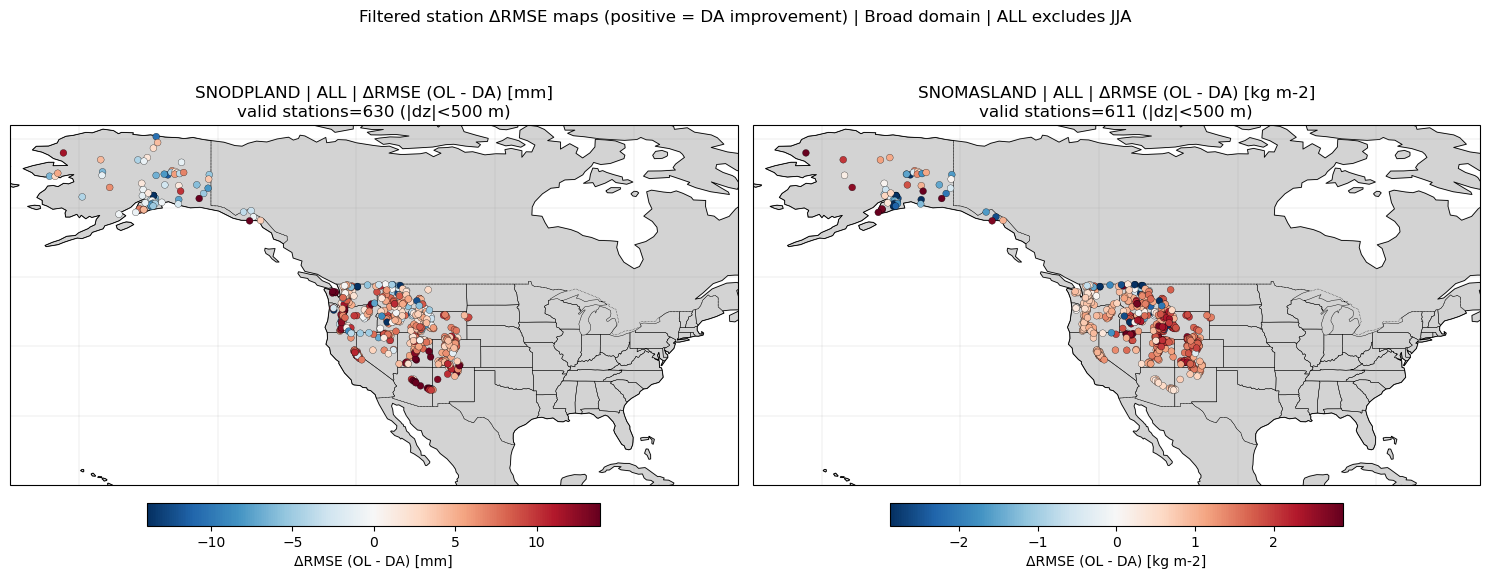

Wrote figure: /Users/amfox/Desktop/geosldas-analysis/projects/SNOTEL/outputs_snotel_ol_da_validation/figures/snotel_station_delta_rmse_map_all_broad_elevfilt500_SMAP_EASEv2_M36_GLOBAL_20000601_20240601.png


/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: inv

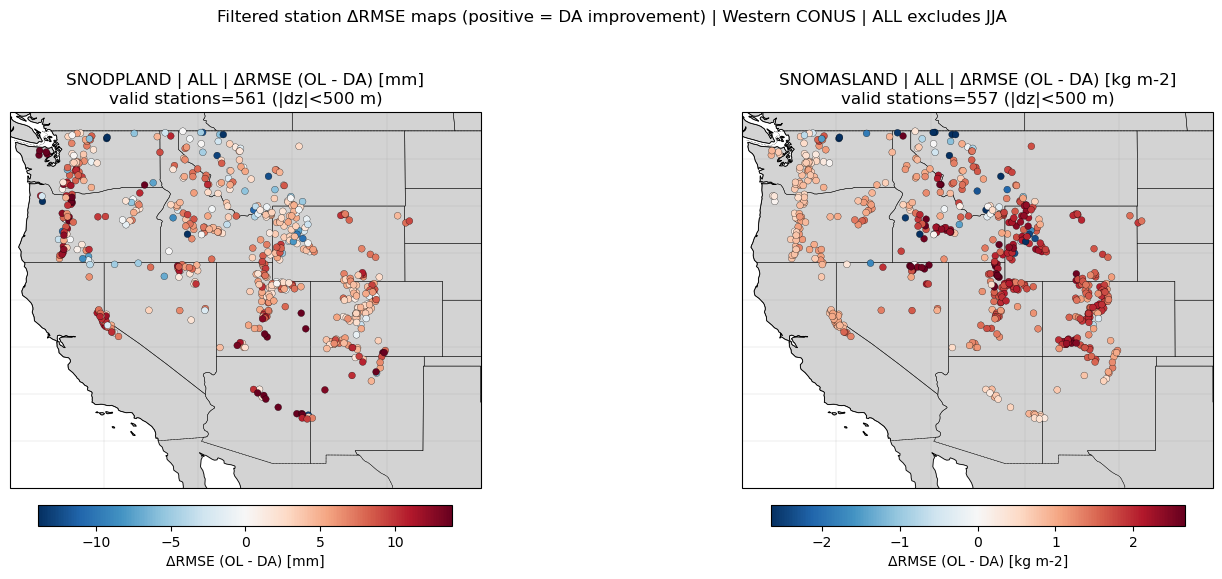

Wrote figure: /Users/amfox/Desktop/geosldas-analysis/projects/SNOTEL/outputs_snotel_ol_da_validation/figures/snotel_station_delta_rmse_map_all_west_conus_elevfilt500_SMAP_EASEv2_M36_GLOBAL_20000601_20240601.png


In [11]:
# -------------------------
# Cartopy maps: station ΔRMSE (OL - DA) for ALL, elevation-filtered sites only
# -------------------------
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
except Exception as exc:
    print(f"Cartopy not available ({exc}); skipping filtered map cell.")
else:
    if "station_metrics_df" not in globals():
        raise NameError("station_metrics_df not found. Run metrics cell first.")

    FIG_DIR_MAP = NOTEBOOK_OUTPUT_DIR / "figures"
    FIG_DIR_MAP.mkdir(parents=True, exist_ok=True)

    ELEV_THRESH_MAP_M = float(globals().get("ELEV_THRESH_M", 500.0))
    SEASON_KEY = "ALL"
    all_def_note = "ALL excludes JJA" if globals().get("EXCLUDE_JJA_FROM_ALL", False) else "ALL includes all months"

    var_cfg = [
        ("SNODPLAND", "mm"),
        ("SNOMASLAND", "kg m-2"),
    ]

    proj = ccrs.PlateCarree()

    # Shared fixed western-CONUS map extent used across map cells.
    WEST_CONUS_EXTENT = list(globals().get("WEST_CONUS_EXTENT", [-125.0, -100.0, 30.0, 50.0]))
    globals()["WEST_CONUS_EXTENT"] = WEST_CONUS_EXTENT

    # Build station filter from OL mapping.
    elev_sub = station_metrics_df.loc[
        (station_metrics_df["season"] == SEASON_KEY) & (station_metrics_df["experiment"] == "OL"),
        ["station", "elev_diff_m"],
    ].drop_duplicates(subset=["station"])

    elev_sub["elev_diff_m"] = pd.to_numeric(elev_sub["elev_diff_m"], errors="coerce")
    station_keep = set(
        elev_sub.loc[
            np.isfinite(elev_sub["elev_diff_m"]) & (np.abs(elev_sub["elev_diff_m"]) < ELEV_THRESH_MAP_M),
            "station",
        ]
        .dropna()
        .unique()
        .tolist()
    )

    print(
        f"Filtered station set: {len(station_keep)} sites with |tile-site elevation| < {ELEV_THRESH_MAP_M:.0f} m"
    )

    def _build_delta_rmse_df_filtered(var_name, unit_label):
        sub = station_metrics_df[
            (station_metrics_df["variable"] == var_name)
            & (station_metrics_df["season"] == SEASON_KEY)
            & (station_metrics_df["station"].isin(station_keep))
        ][["station", "experiment", "rmse", "station_lat", "station_lon"]].copy()

        piv = sub.pivot_table(index="station", columns="experiment", values="rmse", aggfunc="mean")
        lat_s = sub.groupby("station")["station_lat"].first()
        lon_s = sub.groupby("station")["station_lon"].first()

        m = piv.join(lat_s, how="inner").join(lon_s, how="inner")
        if "OL" not in m.columns:
            m["OL"] = np.nan
        if "DA" not in m.columns:
            m["DA"] = np.nan

        m["delta_rmse"] = m["OL"].astype(float) - m["DA"].astype(float)  # positive => DA improved
        if unit_label == "mm":
            m["delta_rmse"] = m["delta_rmse"] * 1000.0

        m = m.reset_index(drop=False)
        m["station_lat"] = pd.to_numeric(m["station_lat"], errors="coerce")
        m["station_lon"] = pd.to_numeric(m["station_lon"], errors="coerce")
        m["delta_rmse"] = pd.to_numeric(m["delta_rmse"], errors="coerce")
        return m

    def _plot_delta_maps_filtered(extent, suffix, title_region, mask_fn=None):
        fig, axes = plt.subplots(1, len(var_cfg), figsize=(15, 5.8), subplot_kw={"projection": proj})
        if len(var_cfg) == 1:
            axes = [axes]

        for ax, (var_name, unit_label) in zip(axes, var_cfg):
            m = _build_delta_rmse_df_filtered(var_name, unit_label)

            lon = m["station_lon"].to_numpy(dtype=float)
            lat = m["station_lat"].to_numpy(dtype=float)
            val = m["delta_rmse"].to_numpy(dtype=float)

            valid = np.isfinite(val) & np.isfinite(lat) & np.isfinite(lon)
            if mask_fn is not None:
                valid &= mask_fn(lon, lat)

            n_valid = int(np.sum(valid))
            vals = val[valid]

            if n_valid > 0:
                vmax = float(np.nanpercentile(np.abs(vals), 95))
                if not np.isfinite(vmax) or vmax <= 0:
                    vmax = float(np.nanmax(np.abs(vals))) if np.any(np.isfinite(vals)) else 1.0
                if not np.isfinite(vmax) or vmax <= 0:
                    vmax = 1.0

                sc = ax.scatter(
                    lon[valid],
                    lat[valid],
                    c=vals,
                    cmap="RdBu_r",
                    vmin=-vmax,
                    vmax=vmax,
                    s=24,
                    edgecolor="k",
                    linewidths=0.2,
                    transform=proj,
                    zorder=3,
                )
                cbar = fig.colorbar(sc, ax=ax, orientation="horizontal", pad=0.04, fraction=0.05)
                cbar.set_label(f"ΔRMSE (OL - DA) [{unit_label}]")
            else:
                ax.text(0.5, 0.5, "No valid stations", transform=ax.transAxes, ha="center", va="center")

            ax.add_feature(cfeature.LAND, color="lightgray", zorder=0)
            ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
            ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=":")
            try:
                ax.add_feature(cfeature.STATES, linewidth=0.3)
            except Exception:
                pass

            ax.set_extent(extent, crs=proj)
            ax.set_title(
                f"{var_name} | ALL | ΔRMSE (OL - DA) [{unit_label}]\n"
                f"valid stations={n_valid} (|dz|<{ELEV_THRESH_MAP_M:.0f} m)"
            )
            ax.gridlines(draw_labels=False, linewidth=0.25, color="0.6", alpha=0.5)

        fig.suptitle(
            f"Filtered station ΔRMSE maps (positive = DA improvement) | {title_region} | {all_def_note}",
            y=0.99,
        )
        plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))

        map_path = FIG_DIR_MAP / f"snotel_station_delta_rmse_map_all_{suffix}_elevfilt{int(ELEV_THRESH_MAP_M)}_{_cache_tag}.png"
        fig.savefig(map_path, dpi=220, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"Wrote figure: {map_path}")

    # Pair 1: broad SNOTEL domain
    _plot_delta_maps_filtered(
        extent=[-170, -65, 20, 72],
        suffix="broad",
        title_region="Broad domain",
        mask_fn=None,
    )

    # Pair 2: western CONUS only
    def _west_mask(lon, lat):
        return (
            (lon >= WEST_CONUS_EXTENT[0])
            & (lon <= WEST_CONUS_EXTENT[1])
            & (lat >= WEST_CONUS_EXTENT[2])
            & (lat <= WEST_CONUS_EXTENT[3])
        )

    # Fixed extent to keep western-CONUS map framing identical across map cells.
    west_extent = WEST_CONUS_EXTENT

    _plot_delta_maps_filtered(
        extent=west_extent,
        suffix="west_conus",
        title_region="Western CONUS",
        mask_fn=_west_mask,
    )


Using all-site map extent: [-169.13297119140626, -98.94718322753906, 30.763993377685548, 73.20777404785156]


/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_7613/1606163051.py:360: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.97))
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: 

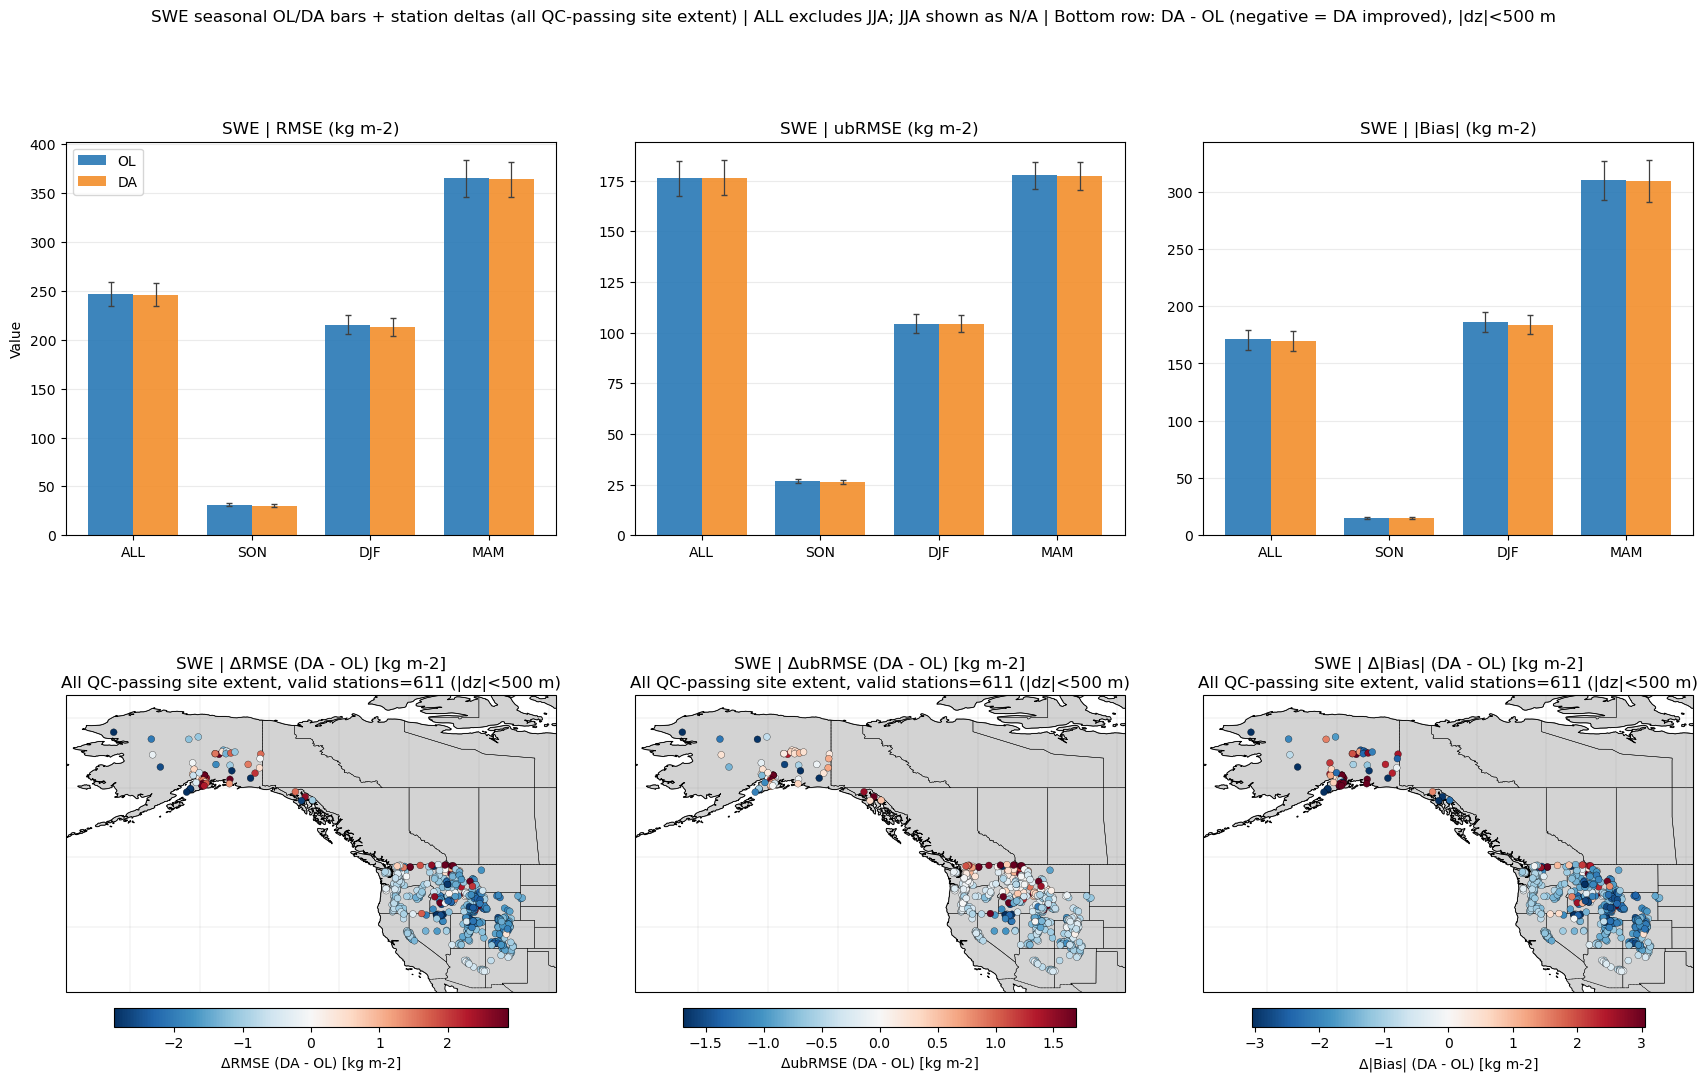

Wrote figure: /Users/amfox/Desktop/geosldas-analysis/projects/SNOTEL/outputs_snotel_ol_da_validation/figures/snotel_swe_2x3_bars_allsites_maps_da_minus_ol_elevfilt500_SMAP_EASEv2_M36_GLOBAL_20000601_20240601.png
Wrote table: /Users/amfox/Desktop/geosldas-analysis/projects/SNOTEL/outputs_snotel_ol_da_validation/tables/snotel_swe_toprow_bar_values_ci_SMAP_EASEv2_M36_GLOBAL_20000601_20240601.csv


,variable,variable_label,metric,metric_label,season,experiment,mean,ci_low,ci_high,n_stations,units,all_definition,delta_definition_for_maps
0,SNOMASLAND,SWE,bias,|Bias|,ALL,DA,169.813754,161.186296,178.518718,878,kg m-2,ALL excludes JJA; JJA shown as N/A,DA - OL (negative = DA improved)
1,SNOMASLAND,SWE,bias,|Bias|,ALL,OL,170.962361,162.005315,179.395040,878,kg m-2,ALL excludes JJA; JJA shown as N/A,DA - OL (negative = DA improved)
2,SNOMASLAND,SWE,bias,|Bias|,DJF,DA,184.007111,175.382208,192.352811,876,kg m-2,ALL excludes JJA; JJA shown as N/A,DA - OL (negative = DA improved)
3,SNOMASLAND,SWE,bias,|Bias|,DJF,OL,186.161404,177.880101,195.014348,876,kg m-2,ALL excludes JJA; JJA shown as N/A,DA - OL (negative = DA improved)
4,SNOMASLAND,SWE,bias,|Bias|,MAM,DA,309.725095,291.203699,327.295234,876,kg m-2,ALL excludes JJA; JJA shown as N/A,DA - OL (negative = DA improved)
5,SNOMASLAND,SWE,bias,|Bias|,MAM,OL,310.319465,293.190735,326.682495,876,kg m-2,ALL excludes JJA; JJA shown as N/A,DA - OL (negative = DA improved)
6,SNOMASLAND,SWE,bias,|Bias|,SON,DA,14.741002,13.911527,15.598009,878,kg m-2,ALL excludes JJA; JJA shown as N/A,DA - OL (negative = DA improved)
7,SNOMASLAND,SWE,bias,|Bias|,SON,OL,15.442212,14.610498,16.311459,878,kg m-2,ALL excludes JJA; JJA shown as N/A,DA - OL (negative = DA improved)
8,SNOMASLAND,SWE,rmse,RMSE,ALL,DA,245.951642,234.409908,257.948309,878,kg m-2,ALL excludes JJA; JJA shown as N/A,DA - OL (negative = DA improved)
9,SNOMASLAND,SWE,rmse,RMSE,ALL,OL,246.844991,234.532273,259.511977,878,kg m-2,ALL excludes JJA; JJA shown as N/A,DA - OL (negative = DA improved)


In [12]:
# -------------------------
# SWE-only 2x3 summary figure + machine-readable bar table
# Top row: seasonal OL/DA bars (RMSE, ubRMSE, |Bias|)
# Bottom row: station maps for SWE deltas (DA - OL), |dz| < 500 m, extent from all QC-passing sites
# -------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
except Exception as exc:
    raise RuntimeError(f"Cartopy is required for bottom-row maps: {exc}")

if "station_metrics_df" not in globals():
    raise NameError("station_metrics_df not found. Run metrics cells first.")

required_cols = {"station", "experiment", "season", "variable", "rmse", "ubrmse", "bias", "station_lat", "station_lon", "elev_diff_m", "units"}
missing_cols = required_cols - set(station_metrics_df.columns)
if missing_cols:
    raise KeyError(f"station_metrics_df missing required columns: {sorted(missing_cols)}")

EXP_OL = str(globals().get("EXP_OL", "OL"))
EXP_DA = str(globals().get("EXP_DA", "DA"))

SEASONS_WITH_ALL = list(globals().get("SEASONS_WITH_ALL", ["ALL", "DJF", "MAM", "JJA", "SON"]))
BAR_SEASONS = [s for s in ["ALL", "SON", "DJF", "MAM"] if s in SEASONS_WITH_ALL]
if "_season_is_na" in globals() and callable(globals()["_season_is_na"]):
    _season_is_na_local = globals()["_season_is_na"]
else:
    _na = {"JJA"} if bool(globals().get("EXCLUDE_JJA_FROM_ALL", False)) else set()
    def _season_is_na_local(season_key: str) -> bool:
        return season_key in _na

ALL_DEF_NOTE = "ALL excludes JJA; JJA shown as N/A" if bool(globals().get("EXCLUDE_JJA_FROM_ALL", False)) else "ALL includes all months"

# Fixed settings for this summary cell
VAR_NAME = "SNOMASLAND"
VAR_LABEL = "SWE"
METRICS = ["rmse", "ubrmse", "bias"]
METRIC_TITLE = {
    "rmse": "RMSE",
    "ubrmse": "ubRMSE",
    "bias": "|Bias|",
}
OL_COLOR = "#2878B5"
DA_COLOR = "#F28E2B"
ELEV_THRESH_M = 500.0
BOOT_N = int(globals().get("BOOT_N", 1000))
BOOT_CI = float(globals().get("BOOT_CI", 95.0))
BOOT_SEED = int(globals().get("BOOT_SEED", 42))

# Unit handling (for consistency with prior cells)
var_base_unit = (
    station_metrics_df[["variable", "units"]]
    .dropna()
    .drop_duplicates("variable")
    .set_index("variable")["units"]
    .to_dict()
)

def _display_unit_local(var_name: str, metric: str) -> str:
    base = str(var_base_unit.get(var_name, "")).strip()
    if metric == "nse":
        return "-"
    if metric != "nse" and base == "m":
        return "mm"
    return base if len(base) > 0 else "-"


def _scale_values_local(var_name: str, metric: str, x):
    arr = np.asarray(x, dtype=float)
    if metric != "nse" and str(var_base_unit.get(var_name, "")).strip() == "m":
        return arr * 1000.0
    return arr


def _bootstrap_mean_ci(vals, n_boot=BOOT_N, ci=BOOT_CI, rng=None):
    x = np.asarray(vals, dtype=float)
    x = x[np.isfinite(x)]
    n = x.size
    if n == 0:
        return np.nan, np.nan, np.nan
    mu = float(np.mean(x))
    if n == 1:
        return mu, mu, mu
    if rng is None:
        rng = np.random.default_rng(BOOT_SEED)
    idx = rng.integers(0, n, size=(int(n_boot), n))
    boot_means = x[idx].mean(axis=1)
    alpha = (100.0 - float(ci)) / 2.0
    lo = float(np.nanpercentile(boot_means, alpha))
    hi = float(np.nanpercentile(boot_means, 100.0 - alpha))
    return mu, lo, hi


# Build bar summary table directly from station_metrics_df (SWE only)
rng = np.random.default_rng(BOOT_SEED)
bar_rows = []
for metric in METRICS:
    for season_key in BAR_SEASONS:
        for exp_key in [EXP_OL, EXP_DA]:
            sub = station_metrics_df[
                (station_metrics_df["variable"] == VAR_NAME)
                & (station_metrics_df["season"] == season_key)
                & (station_metrics_df["experiment"] == exp_key)
            ]
            vals = sub[metric].to_numpy(dtype=float)
            if metric == "bias":
                vals = np.abs(vals)
            vals = _scale_values_local(VAR_NAME, metric, vals)
            n_station = int(np.sum(np.isfinite(vals)))

            if _season_is_na_local(season_key):
                mu, lo, hi = np.nan, np.nan, np.nan
                n_station = 0
            else:
                mu, lo, hi = _bootstrap_mean_ci(vals, rng=rng)

            bar_rows.append(
                {
                    "variable": VAR_NAME,
                    "variable_label": VAR_LABEL,
                    "metric": metric,
                    "metric_label": METRIC_TITLE[metric],
                    "season": season_key,
                    "experiment": exp_key,
                    "mean": float(mu) if np.isfinite(mu) else np.nan,
                    "ci_low": float(lo) if np.isfinite(lo) else np.nan,
                    "ci_high": float(hi) if np.isfinite(hi) else np.nan,
                    "n_stations": int(n_station),
                    "units": _display_unit_local(VAR_NAME, metric),
                    "all_definition": ALL_DEF_NOTE,
                    "delta_definition_for_maps": "DA - OL (negative = DA improved)",
                }
            )

swe_bar_table_df = pd.DataFrame(bar_rows)

# Station filter for maps: |tile-site elevation| < 500 m from OL mapping
elev_sub = station_metrics_df.loc[
    (station_metrics_df["season"] == "ALL")
    & (station_metrics_df["experiment"] == EXP_OL),
    ["station", "elev_diff_m"],
].drop_duplicates(subset=["station"])

elev_sub["elev_diff_m"] = pd.to_numeric(elev_sub["elev_diff_m"], errors="coerce")
station_keep = set(
    elev_sub.loc[
        np.isfinite(elev_sub["elev_diff_m"]) & (np.abs(elev_sub["elev_diff_m"]) < ELEV_THRESH_M),
        "station",
    ]
    .dropna()
    .unique()
    .tolist()
)

def _build_delta_map_df(metric_key: str):
    sub = station_metrics_df[
        (station_metrics_df["variable"] == VAR_NAME)
        & (station_metrics_df["season"] == "ALL")
        & (station_metrics_df["station"].isin(station_keep))
    ][["station", "experiment", metric_key, "station_lat", "station_lon"]].copy()

    piv = sub.pivot_table(index="station", columns="experiment", values=metric_key, aggfunc="mean")
    lat_s = sub.groupby("station")["station_lat"].first()
    lon_s = sub.groupby("station")["station_lon"].first()

    m = piv.join(lat_s, how="inner").join(lon_s, how="inner")
    if EXP_OL not in m.columns:
        m[EXP_OL] = np.nan
    if EXP_DA not in m.columns:
        m[EXP_DA] = np.nan

    ol = pd.to_numeric(m[EXP_OL], errors="coerce").to_numpy(dtype=float)
    da = pd.to_numeric(m[EXP_DA], errors="coerce").to_numpy(dtype=float)
    if metric_key == "bias":
        # For bias use absolute magnitude; lower is better.
        ol = np.abs(ol)
        da = np.abs(da)

    delta = da - ol  # requested convention: DA - OL (negative is good)

    out = pd.DataFrame({
        "station_lat": pd.to_numeric(m["station_lat"], errors="coerce"),
        "station_lon": pd.to_numeric(m["station_lon"], errors="coerce"),
        "delta": delta,
    })
    return out


# Tight extent around all QC-passing SWE sites (not limited to metric-valid deltas)
sites_for_extent = station_metrics_df.loc[
    (station_metrics_df["variable"] == VAR_NAME)
    & (station_metrics_df["season"] == "ALL")
    & (station_metrics_df["experiment"] == EXP_OL)
    & (station_metrics_df["station"].isin(station_keep)),
    ["station", "station_lat", "station_lon"],
].drop_duplicates(subset=["station"]).copy()

sites_for_extent["station_lat"] = pd.to_numeric(sites_for_extent["station_lat"], errors="coerce")
sites_for_extent["station_lon"] = pd.to_numeric(sites_for_extent["station_lon"], errors="coerce")

_lon = sites_for_extent["station_lon"].to_numpy(dtype=float)
_lat = sites_for_extent["station_lat"].to_numpy(dtype=float)
_ok = np.isfinite(_lon) & np.isfinite(_lat)

if np.any(_ok):
    lon_all = _lon[_ok]
    lat_all = _lat[_ok]

    lon_min = float(np.nanmin(lon_all))
    lon_max = float(np.nanmax(lon_all))
    lat_min = float(np.nanmin(lat_all))
    lat_max = float(np.nanmax(lat_all))

    dlon = max(lon_max - lon_min, 1.0)
    dlat = max(lat_max - lat_min, 1.0)
    pad_lon = max(1.0, 0.08 * dlon)
    pad_lat = max(1.0, 0.08 * dlat)

    TIGHT_EXTENT = [
        max(-179.9, lon_min - pad_lon),
        min(179.9, lon_max + pad_lon),
        max(-89.9, lat_min - pad_lat),
        min(89.9, lat_max + pad_lat),
    ]
else:
    # Fallback if no QC-passing station coordinates are available.
    TIGHT_EXTENT = [-170.0, -60.0, 20.0, 75.0]

print(f"Using all-site map extent: {TIGHT_EXTENT}")


# Build 2x3 figure (top: bars, bottom: maps)
fig = plt.figure(figsize=(21, 11.5))
gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 1.0], hspace=0.25, wspace=0.16)

# --- Top row: bars ---
x = np.arange(len(BAR_SEASONS), dtype=float)
bar_w = 0.38

for j, metric in enumerate(METRICS):
    ax = fig.add_subplot(gs[0, j])

    sub = swe_bar_table_df[swe_bar_table_df["metric"] == metric].copy()
    piv_mean = sub.pivot_table(index="season", columns="experiment", values="mean", aggfunc="first").reindex(BAR_SEASONS)
    piv_lo = sub.pivot_table(index="season", columns="experiment", values="ci_low", aggfunc="first").reindex(BAR_SEASONS)
    piv_hi = sub.pivot_table(index="season", columns="experiment", values="ci_high", aggfunc="first").reindex(BAR_SEASONS)

    y_ol = piv_mean.get(EXP_OL, pd.Series(index=BAR_SEASONS, dtype=float)).to_numpy(dtype=float)
    y_da = piv_mean.get(EXP_DA, pd.Series(index=BAR_SEASONS, dtype=float)).to_numpy(dtype=float)

    ol_lo = piv_lo.get(EXP_OL, pd.Series(index=BAR_SEASONS, dtype=float)).to_numpy(dtype=float)
    ol_hi = piv_hi.get(EXP_OL, pd.Series(index=BAR_SEASONS, dtype=float)).to_numpy(dtype=float)
    da_lo = piv_lo.get(EXP_DA, pd.Series(index=BAR_SEASONS, dtype=float)).to_numpy(dtype=float)
    da_hi = piv_hi.get(EXP_DA, pd.Series(index=BAR_SEASONS, dtype=float)).to_numpy(dtype=float)

    yerr_ol = np.vstack([y_ol - ol_lo, ol_hi - y_ol])
    yerr_da = np.vstack([y_da - da_lo, da_hi - y_da])
    yerr_ol = np.where(np.isfinite(yerr_ol), np.maximum(0.0, yerr_ol), np.nan)
    yerr_da = np.where(np.isfinite(yerr_da), np.maximum(0.0, yerr_da), np.nan)

    ax.bar(
        x - bar_w / 2,
        y_ol,
        width=bar_w,
        color=OL_COLOR,
        alpha=0.9,
        yerr=yerr_ol,
        capsize=2,
        error_kw={"elinewidth": 0.9, "ecolor": "0.25"},
        label=EXP_OL,
    )
    ax.bar(
        x + bar_w / 2,
        y_da,
        width=bar_w,
        color=DA_COLOR,
        alpha=0.9,
        yerr=yerr_da,
        capsize=2,
        error_kw={"elinewidth": 0.9, "ecolor": "0.25"},
        label=EXP_DA,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(BAR_SEASONS)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    unit = _display_unit_local(VAR_NAME, metric)
    ax.set_title(f"SWE | {METRIC_TITLE[metric]} ({unit})")
    if j == 0:
        ax.set_ylabel("Value")
        ax.legend(loc="upper left")

# --- Bottom row: maps ---
proj = ccrs.PlateCarree()
for j, metric in enumerate(METRICS):
    ax = fig.add_subplot(gs[1, j], projection=proj)

    m = _build_delta_map_df(metric)
    lon = m["station_lon"].to_numpy(dtype=float)
    lat = m["station_lat"].to_numpy(dtype=float)
    val = m["delta"].to_numpy(dtype=float)

    valid = np.isfinite(val) & np.isfinite(lat) & np.isfinite(lon)

    n_valid = int(np.sum(valid))
    vals = val[valid]

    if n_valid > 0:
        vmax = float(np.nanpercentile(np.abs(vals), 95))
        if not np.isfinite(vmax) or vmax <= 0:
            vmax = float(np.nanmax(np.abs(vals))) if np.any(np.isfinite(vals)) else 1.0
        if not np.isfinite(vmax) or vmax <= 0:
            vmax = 1.0

        sc = ax.scatter(
            lon[valid],
            lat[valid],
            c=vals,
            cmap="RdBu_r",
            vmin=-vmax,
            vmax=vmax,
            s=24,
            edgecolor="k",
            linewidths=0.2,
            transform=proj,
            zorder=3,
        )
        cbar = fig.colorbar(sc, ax=ax, orientation="horizontal", pad=0.04, fraction=0.05)
        unit = _display_unit_local(VAR_NAME, metric)
        cbar.set_label(f"Δ{METRIC_TITLE[metric]} (DA - OL) [{unit}]")
    else:
        ax.text(0.5, 0.5, "No valid stations", transform=ax.transAxes, ha="center", va="center")

    ax.add_feature(cfeature.LAND, color="lightgray", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=":")
    try:
        ax.add_feature(cfeature.STATES, linewidth=0.3)
    except Exception:
        pass

    ax.set_extent(TIGHT_EXTENT, crs=proj)
    unit = _display_unit_local(VAR_NAME, metric)
    ax.set_title(
        f"SWE | Δ{METRIC_TITLE[metric]} (DA - OL) [{unit}]\n"
        f"All QC-passing site extent, valid stations={n_valid} (|dz|<{int(ELEV_THRESH_M)} m)"
    )
    ax.gridlines(draw_labels=False, linewidth=0.25, color="0.6", alpha=0.5)

fig.suptitle(
    f"SWE seasonal OL/DA bars + station deltas (all QC-passing site extent) | {ALL_DEF_NOTE} | "
    f"Bottom row: DA - OL (negative = DA improved), |dz|<{int(ELEV_THRESH_M)} m",
    y=0.995,
)
plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.97))

fig_dir = NOTEBOOK_OUTPUT_DIR / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
out_fig = fig_dir / f"snotel_swe_2x3_bars_allsites_maps_da_minus_ol_elevfilt{int(ELEV_THRESH_M)}_{_cache_tag}.png"
fig.savefig(out_fig, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Wrote figure: {out_fig}")

# Machine-readable table for top-row bar panels
table_dir = NOTEBOOK_OUTPUT_DIR / "tables"
table_dir.mkdir(parents=True, exist_ok=True)
out_csv = table_dir / f"snotel_swe_toprow_bar_values_ci_{_cache_tag}.csv"
swe_bar_table_df.to_csv(out_csv, index=False)
print(f"Wrote table: {out_csv}")

display(swe_bar_table_df.sort_values(["metric", "season", "experiment"]).reset_index(drop=True))

Alaska stations passing QC (|dz|<500 m): 72


,station,station_lat,station_lon,elev_diff_m
0,1001:AK:SNTL,58.186001,-133.832169,153.797806
1,1002:AK:SNTL,61.389488,-150.021896,-25.900101
2,1003:AK:SNTL,59.745209,-151.258392,-93.516411
3,1035:AK:SNTL,61.377270,-148.999176,153.607986
4,1036:AK:SNTL,64.564598,-164.292572,81.145004
...,...,...,...,...
67,967:AK:SNTL,62.132450,-150.043915,37.020992
68,968:AK:SNTL,68.616524,-149.303299,87.885422
69,973:AK:SNTL,64.549881,-163.483994,-16.447401
70,986:AK:SNTL,64.996193,-163.105133,158.581894


/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: inv

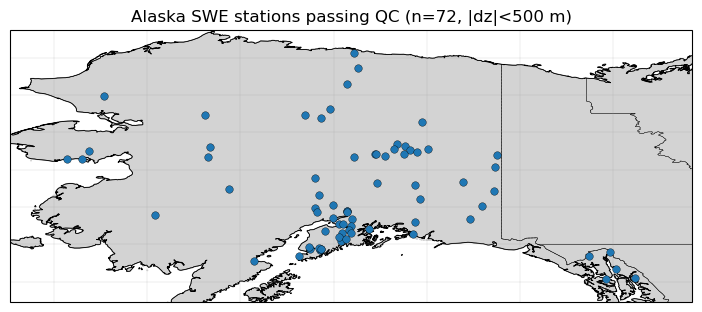

Wrote figure: /Users/amfox/Desktop/geosldas-analysis/projects/SNOTEL/outputs_snotel_ol_da_validation/figures/snotel_alaska_sites_qc_map_elevfilt500_SMAP_EASEv2_M36_GLOBAL_20000601_20240601.png


In [13]:
# -------------------------
# Alaska-only map: stations that pass QC (including |dz|<500 m)
# -------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
except Exception as exc:
    raise RuntimeError(f"Cartopy is required for this map: {exc}")

if "station_metrics_df" not in globals():
    raise NameError("station_metrics_df not found. Run metrics cells first.")

REQ = {"station", "variable", "season", "experiment", "station_lat", "station_lon", "elev_diff_m"}
missing = REQ - set(station_metrics_df.columns)
if missing:
    raise KeyError(f"station_metrics_df missing columns: {sorted(missing)}")

EXP_OL = str(globals().get("EXP_OL", "OL"))
VAR_NAME = "SNOMASLAND"   # SWE
SEASON_KEY = "ALL"
ELEV_THRESH_M = 500.0

# Build one-row-per-station metadata from OL mapping
st = station_metrics_df.loc[
    (station_metrics_df["variable"] == VAR_NAME)
    & (station_metrics_df["season"] == SEASON_KEY)
    & (station_metrics_df["experiment"] == EXP_OL),
    ["station", "station_lat", "station_lon", "elev_diff_m"],
].drop_duplicates(subset=["station"]).copy()

st["station_lat"] = pd.to_numeric(st["station_lat"], errors="coerce")
st["station_lon"] = pd.to_numeric(st["station_lon"], errors="coerce")
st["elev_diff_m"] = pd.to_numeric(st["elev_diff_m"], errors="coerce")

# QC filter for this map: finite lon/lat and |dz| < 500 m
qc = (
    np.isfinite(st["station_lat"].to_numpy(dtype=float))
    & np.isfinite(st["station_lon"].to_numpy(dtype=float))
    & np.isfinite(st["elev_diff_m"].to_numpy(dtype=float))
    & (np.abs(st["elev_diff_m"].to_numpy(dtype=float)) < ELEV_THRESH_M)
)

# Alaska bounding box (covers mainland + most Aleutians in this domain)
ak = (
    (st["station_lat"].to_numpy(dtype=float) >= 50.0)
    & (st["station_lat"].to_numpy(dtype=float) <= 72.5)
    & (st["station_lon"].to_numpy(dtype=float) >= -170.0)
    & (st["station_lon"].to_numpy(dtype=float) <= -130.0)
)

plot_df = st.loc[qc & ak].copy().reset_index(drop=True)

print(f"Alaska stations passing QC (|dz|<{int(ELEV_THRESH_M)} m): {len(plot_df)}")
if len(plot_df) == 0:
    print("No Alaska stations passed this QC filter.")
else:
    display(plot_df.sort_values("station").reset_index(drop=True))

    proj = ccrs.PlateCarree()
    fig, ax = plt.subplots(1, 1, figsize=(8.8, 6.0), subplot_kw={"projection": proj})

    ax.add_feature(cfeature.LAND, color="lightgray", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=":")
    try:
        ax.add_feature(cfeature.STATES, linewidth=0.25)
    except Exception:
        pass

    lon = plot_df["station_lon"].to_numpy(dtype=float)
    lat = plot_df["station_lat"].to_numpy(dtype=float)
    ax.scatter(
        lon,
        lat,
        s=30,
        color="#1f77b4",
        edgecolor="k",
        linewidths=0.25,
        transform=proj,
        zorder=3,
    )

    # Tight Alaska extent around retained stations
    lon_min, lon_max = float(np.nanmin(lon)), float(np.nanmax(lon))
    lat_min, lat_max = float(np.nanmin(lat)), float(np.nanmax(lat))
    dlon = max(lon_max - lon_min, 1.0)
    dlat = max(lat_max - lat_min, 1.0)
    pad_lon = max(1.0, 0.10 * dlon)
    pad_lat = max(1.0, 0.10 * dlat)
    extent = [
        max(-179.9, lon_min - pad_lon),
        min(179.9, lon_max + pad_lon),
        max(-89.9, lat_min - pad_lat),
        min(89.9, lat_max + pad_lat),
    ]
    ax.set_extent(extent, crs=proj)

    ax.gridlines(draw_labels=False, linewidth=0.25, color="0.6", alpha=0.5)
    ax.set_title(f"Alaska SWE stations passing QC (n={len(plot_df)}, |dz|<{int(ELEV_THRESH_M)} m)")

    out_dir = NOTEBOOK_OUTPUT_DIR / "figures"
    out_dir.mkdir(parents=True, exist_ok=True)
    out_fig = out_dir / f"snotel_alaska_sites_qc_map_elevfilt{int(ELEV_THRESH_M)}_{_cache_tag}.png"
    fig.savefig(out_fig, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Wrote figure: {out_fig}")